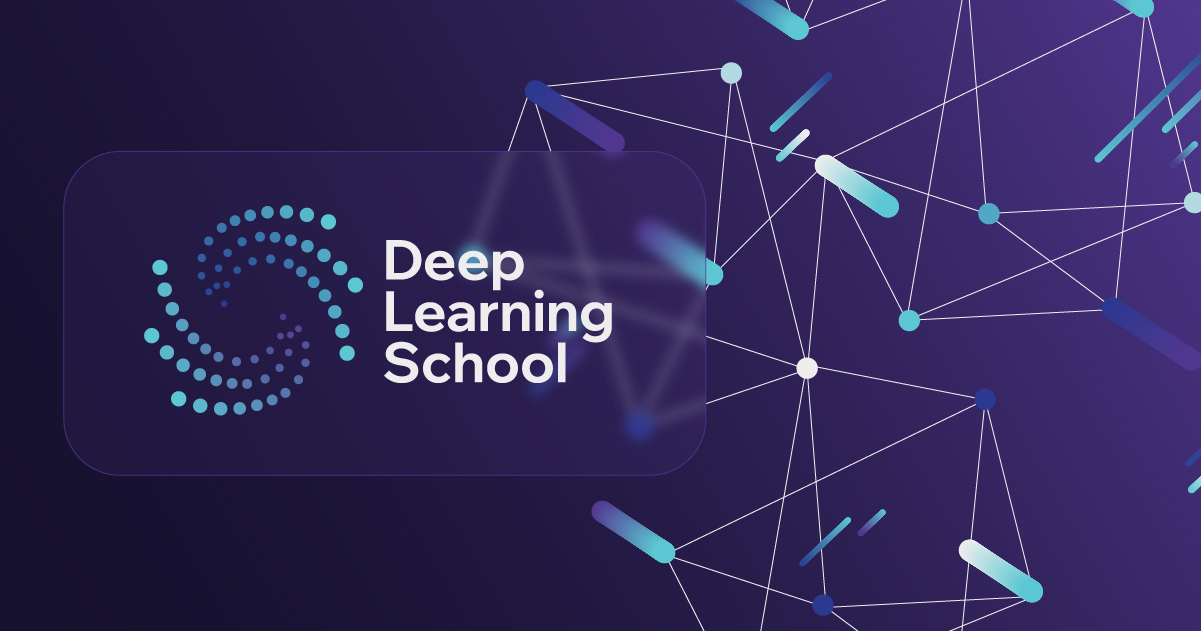


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

from torchvision import transforms

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [106]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /kaggle/input/datasets/jessicali9530/lfw-dataset


In [107]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /kaggle/input/datasets/averkij/lfw-attributes


In [108]:
DATASET_PATH ="/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled"
ATTRIBUTES_PATH = "/kaggle/input/datasets/averkij/lfw-attributes/lfw_attributes.txt"

In [109]:
def fetch_dataset(dx=80, dy=80, dimx=48, dimy=48):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [110]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [149]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_attrs, val_attrs = train_test_split(images, attrs, test_size=0.2)
train_images = torch.from_numpy(train_images).permute(0, 3, 1, 2).float() / 255.0
val_images = torch.from_numpy(val_images).permute(0, 3, 1, 2).float() / 255.0

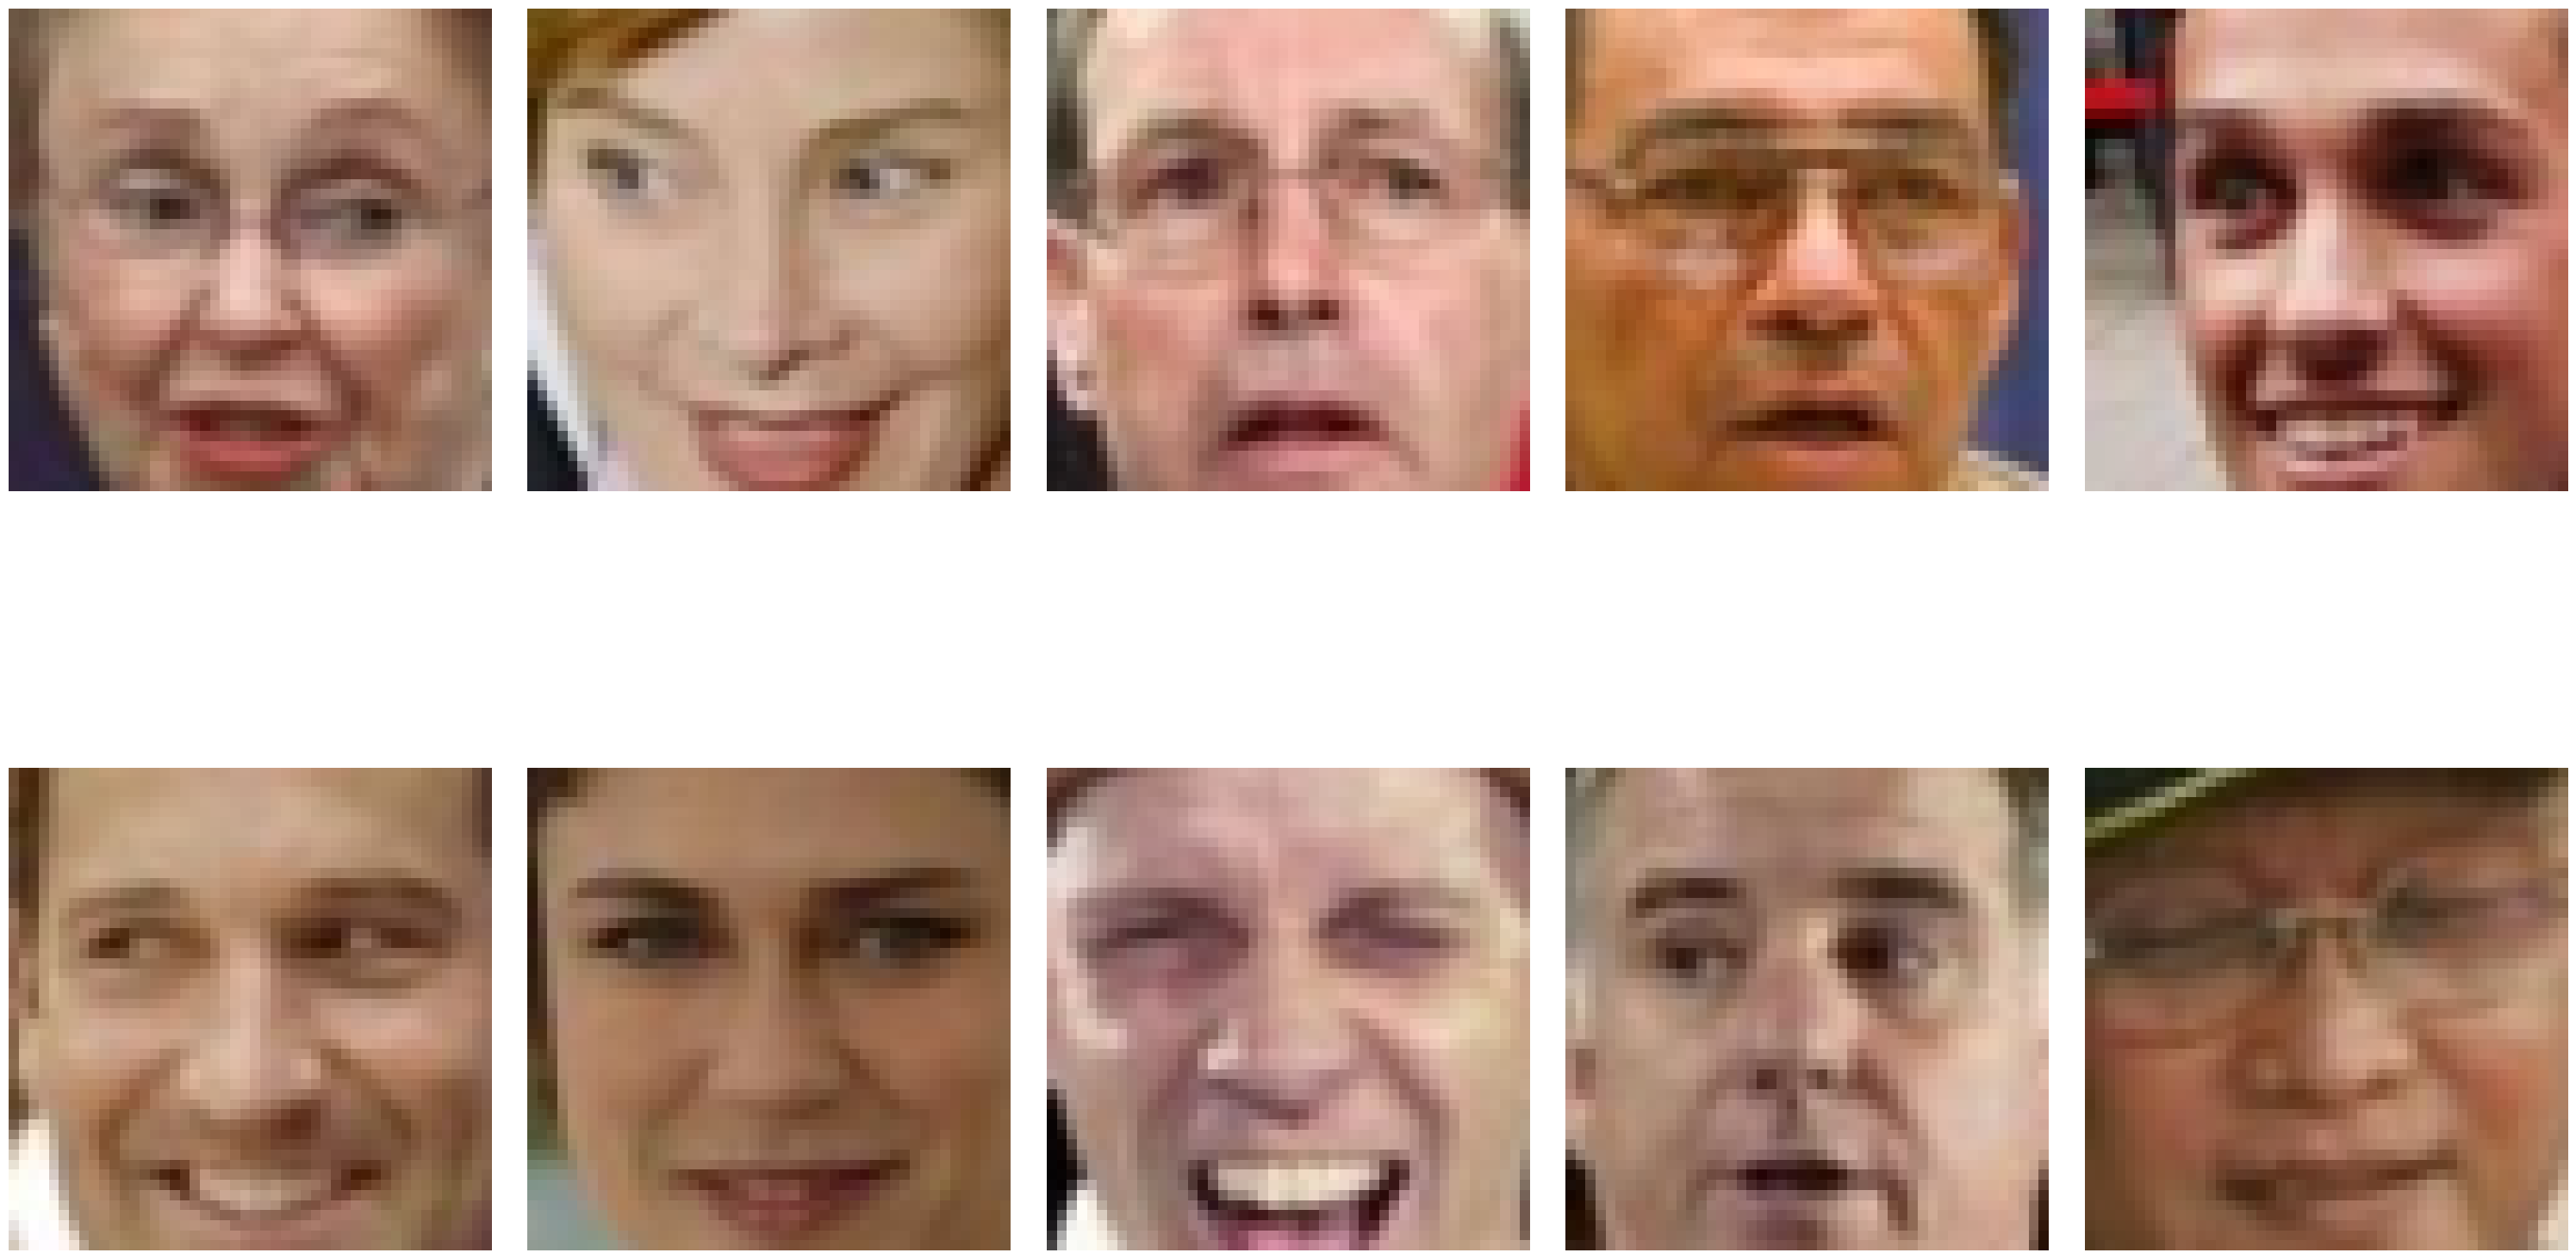

In [150]:
plt.figure(figsize=(30, 30))
for i, image in enumerate(train_images[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(image.permute(1, 2, 0))
    plt.tight_layout()
    plt.axis('off')

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



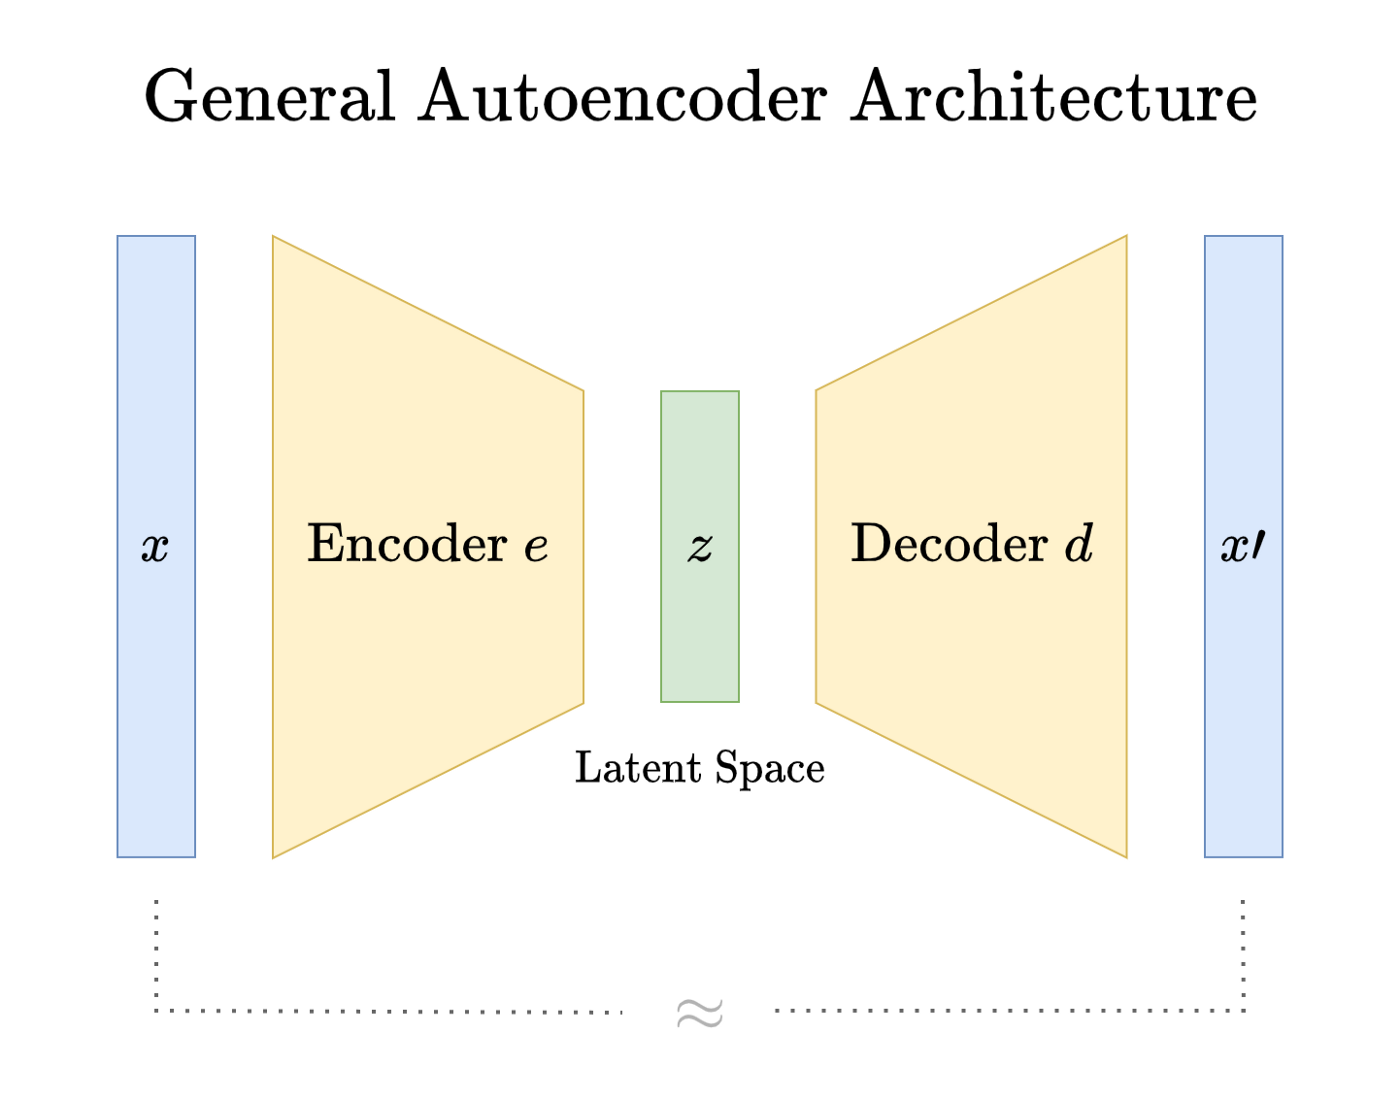

In [ ]:
dim_code = 64 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
import torch.nn.functional as F

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, pool=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool = pool

    def forward(self, x):
        x = self.block(x)
        return F.max_pool2d(x, 2) if self.pool else x

class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, padding=1, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, 
                               padding=padding, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Autoencoder(nn.Module):
    def __init__(self, in_channels, dim_code):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, dim_code)
        )

        self.decoder = nn.Sequential(
            TransposeConvBlock(dim_code, dim_code//2),
            TransposeConvBlock(dim_code//2, dim_code//4),
            nn.ConvTranspose2d(dim_code//4, in_channels, kernel_size=4, padding=1, stride=2, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):

        # реализуйте forward проход автоэнкодера
        # в качестве возвращаемых переменных -- латентное представление картинки (latent_code)
        # и полученная реконструкция изображения (reconstruction)

        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

    def sample(self, z):
        return self.decoder(z)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [ ]:
from IPython.display import clear_output


def plot_reconstruction(images, pred_images, epoch=None, max_cols=5):
  images = images.detach().cpu()
  pred_images = pred_images.detach().cpu()

  ncols = min(len(images), max_cols)

  fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 6))
  if ncols == 1:
    axes = axes[:, None]

  if epoch is not None:
    fig.suptitle(f"Reconstruction at Epoch {epoch}", fontsize=14, y=1.02)

  for i in range(ncols):
    img = images[i].permute(1, 2, 0).clip(0, 1)
    pred = pred_images[i].permute(1, 2, 0).clip(0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Real {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(pred)
    axes[1, i].set_title(f"Reconstructed {i}")
    axes[1, i].axis("off")

  plt.tight_layout()
  plt.show()

In [ ]:
from tqdm.auto import tqdm

In [ ]:
def train_autoencoder(model, train_loader, val_loader, optimizer, loss_func, device, epochs=20, visualize_every=5):
    train_losses = []
    val_losses = []

    for _e in range(epochs):
        model.train()
        train_bar = tqdm(train_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Train]")
        temp_train_loss = 0
        temp_val_loss = 0
        for images in train_bar:
            images = images.to(device)
            predict, _ = model(images)
            loss = loss_func(predict, images)
            temp_train_loss += loss.item()

            train_bar.set_postfix(
                {
                    "loss": f"{loss:.4f}"
                }
            )
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_bar = tqdm(val_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Val]")
            for i, images in enumerate(val_bar):
                images = images.to(device)
                predict, _ = model(images)
                loss = loss_func(predict, images)
                temp_val_loss += loss.item()

                val_bar.set_postfix(
                    {
                        "loss": f"{loss:.4f}"
                    }
                )

                if _e % visualize_every == 0 and i == 0:
                    plot_reconstruction(images, predict, epoch=_e + 1)

        train_losses.append(temp_train_loss / len(train_loader))
        val_losses.append(temp_val_loss / len(val_loader))

    return train_losses, val_losses

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(train_images, batch_size=128, shuffle=True, )
                          #num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_images, batch_size=128, shuffle=False, )
                          #num_workers=2, pin_memory=True, persistent_workers=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [ ]:
criterion = nn.MSELoss()
model = Autoencoder(in_channels=3, dim_code=dim_code).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

In [ ]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
train_losses, val_losses = train_autoencoder(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=criterion,
    device=device,
    epochs=50,
    visualize_every=10
)

In [ ]:
def plot_losses(train_losses, val_losses=None):
  epochs = range(1, len(train_losses) + 1)

  plt.figure(figsize=(9, 5))
  plt.plot(
      epochs,
      train_losses,
      label="Train Loss",
      color="#1f77b4",
      linewidth=2,
      marker="o",
      markersize=4,
  )

  if val_losses is not None:
    plt.plot(
        epochs,
        val_losses,
        label="Val Loss",
        color="#ff7f0e",
        linewidth=2,
        marker="s",
        markersize=4,
    )

  plt.title("Динамика Loss по эпохам", fontsize=13, fontweight="bold")
  plt.xlabel("Эпоха", fontsize=11)
  plt.ylabel("Loss", fontsize=11)
  plt.xticks(epochs)
  plt.grid(True, linestyle="--", alpha=0.6)
  plt.legend(frameon=True, fontsize=11)
  plt.tight_layout()
  plt.show()

In [ ]:
plot_losses(train_losses, val_losses)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

In [ ]:
pred, _ = model(val_images[10:15])
plot_reconstruction(val_images[10:15], pred)

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [ ]:
# сгенерируем 36 рандомных векторов размера latent_space
batch_size = 36
latent_h, latent_w = 6, 6  # размер латентной карты после энкодера

z = torch.randn(batch_size, dim_code, latent_h, latent_w, device=device)
with torch.no_grad():
    output = model.module.sample(z)

In [ ]:
plot_reconstruction(torch.zeros(1, 3, 48, 48), output)

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
smile_col = [col for col in attrs.columns if "smil" in col.lower()][0]

# 2. Непрерывный скор уверенности
smile_scores = attrs[smile_col].values

# 3. Бинарная маска: True / False (или 1 и 0)
is_smiling = smile_scores > 0

In [ ]:
import matplotlib.pyplot as plt

# Самые широкие улыбки и самые неулыбающиеся лица
top_smiling_idx = smile_scores.argsort()[-5:]  # топ-5 улыбок
top_serious_idx = smile_scores.argsort()[:5]  # топ-5 серьезных лиц

# Визуализация
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(top_smiling_idx):
  axes[0, i].imshow(images[idx])
  axes[0, i].set_title(f"Smile: {smile_scores[idx]:.2f}")
  axes[0, i].axis("off")

for i, idx in enumerate(top_serious_idx):
  axes[1, i].imshow(images[idx])
  axes[1, i].set_title(f"No smile: {smile_scores[idx]:.2f}")
  axes[1, i].axis("off")

axes[0, 0].set_ylabel("Smiling", fontsize=14)
axes[1, 0].set_ylabel("Not Smiling", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
top_smiling_idx = smile_scores.argsort()[-15:]
top_serious_idx = smile_scores.argsort()[:15]

top_smiling_images = torch.from_numpy(images[top_smiling_idx]).permute(0, 3, 1, 2).float() / 255.
top_serious_images = torch.from_numpy(images[top_serious_idx]).permute(0, 3, 1, 2).float() / 255.

In [ ]:
_, smiling_latents = model(top_smiling_images.to(device))
_, serious_latents = model(top_serious_images.to(device))

mean_smiling_latent = smiling_latents.mean(dim=0)
mean_serious_latent = serious_latents.mean(dim=0)
mean_diff_latent = mean_smiling_latent - mean_serious_latent

smiling_serious_latent = serious_latents[0] + mean_diff_latent

In [ ]:
serious_image = torch.from_numpy(images[top_serious_idx[0]]).float() / 255.
smiling_serious_image = model.module.sample(smiling_serious_latent.unsqueeze(0)).squeeze(0).permute(1, 2, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(serious_image)
axes[1].imshow(smiling_serious_image.detach().cpu())

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [26]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,
                                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False,
                                         num_workers=2, pin_memory=True, persistent_workers=True)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [15]:
dim_code = 64

In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, pool=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool = pool

    def forward(self, x):
        x = self.block(x)
        return F.max_pool2d(x, 2) if self.pool else x

class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, padding=1, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, 
                               padding=padding, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)



In [17]:
class VAE(nn.Module):
    def __init__(self, in_channels, dim_code):
        super().__init__()
        self.dim_code = dim_code
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64, pool=False),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(7 * 7 * 64, dim_code)
        self.fc_logsigma = nn.Linear(7 * 7 * 64, dim_code)

        self.decoder = nn.Sequential(
            TransposeConvBlock(64, 32),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, padding=1, stride=2, bias=True),
            nn.Sigmoid()
        )
        self.decoder_linear = nn.Linear(dim_code, 7 * 7 * 64)

    def encode(self, x):
        x = self.encoder(x)

        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(logsigma)

            return mu + (eps * std)
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        z = self.decoder_linear(z).view(-1, 64, 7, 7)
        reconstruction = self.decoder(z)

        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        sample = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(sample)
        
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [18]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = 1 + 2 * logsigma - mu**2 - torch.exp(2*logsigma)
    return -1/2 * loss.sum(dim=-1).mean()

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    bce = F.binary_cross_entropy(reconstruction, x, reduction="none")
    recon_per_sample = bce.sum(dim=[1, 2, 3])
    return recon_per_sample.mean()

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [19]:
from IPython.display import clear_output


def plot_reconstruction(images, pred_images, epoch=None, max_cols=5):
  images = images.detach().cpu()
  pred_images = pred_images.detach().cpu()

  ncols = min(len(images), max_cols)

  fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 6))
  if ncols == 1:
    axes = axes[:, None]

  if epoch is not None:
    fig.suptitle(f"Reconstruction at Epoch {epoch}", fontsize=14, y=1.02)

  for i in range(ncols):
    img = images[i].permute(1, 2, 0).clip(0, 1)
    pred = pred_images[i].permute(1, 2, 0).clip(0, 1)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Real {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(pred, cmap='gray')
    axes[1, i].set_title(f"Reconstructed {i}")
    axes[1, i].axis("off")

  plt.tight_layout()
  plt.show()

In [20]:
from tqdm.auto import tqdm

In [21]:
def train_autoencoder(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_func,
    device,
    epochs=20,
    visualize_every=5,
):
  train_losses = []
  val_losses = []

  for _e in range(epochs):
    # --- Обучение ---
    model.train()
    train_bar = tqdm(
        train_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Train]"
    )
    total_train_loss = 0.0

    for images, _ in train_bar:
      images = images.to(device)

      optimizer.zero_grad()
      mu, logsigma, predict = model(images)
      loss = loss_func(images, mu, logsigma, predict)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item() * images.size(0)
      train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- Валидация ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
      val_bar = tqdm(
          val_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Val]"
      )
      for i, (images, _) in enumerate(val_bar):
        images = images.to(device)
        mu, logsigma, predict = model(images)
        loss = loss_func(images, mu, logsigma, predict)

        total_val_loss += loss.item() * images.size(0)
        val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        if _e % visualize_every == 0 and i == 0:
          plot_reconstruction(images, predict, epoch=_e + 1)

    epoch_train_loss = total_train_loss / len(train_loader.dataset)
    epoch_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --- Шаг планировщика в конце эпохи ---
    if scheduler is not None:
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(epoch_val_loss)  # передаем валидационный лосс
      elif not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step()

  return train_losses, val_losses

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
criterion = loss_vae
model = VAE(in_channels=1, dim_code=dim_code).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=11, eta_min=1e-5)

In [24]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

Train on 2 GPUs


Epoch 1/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

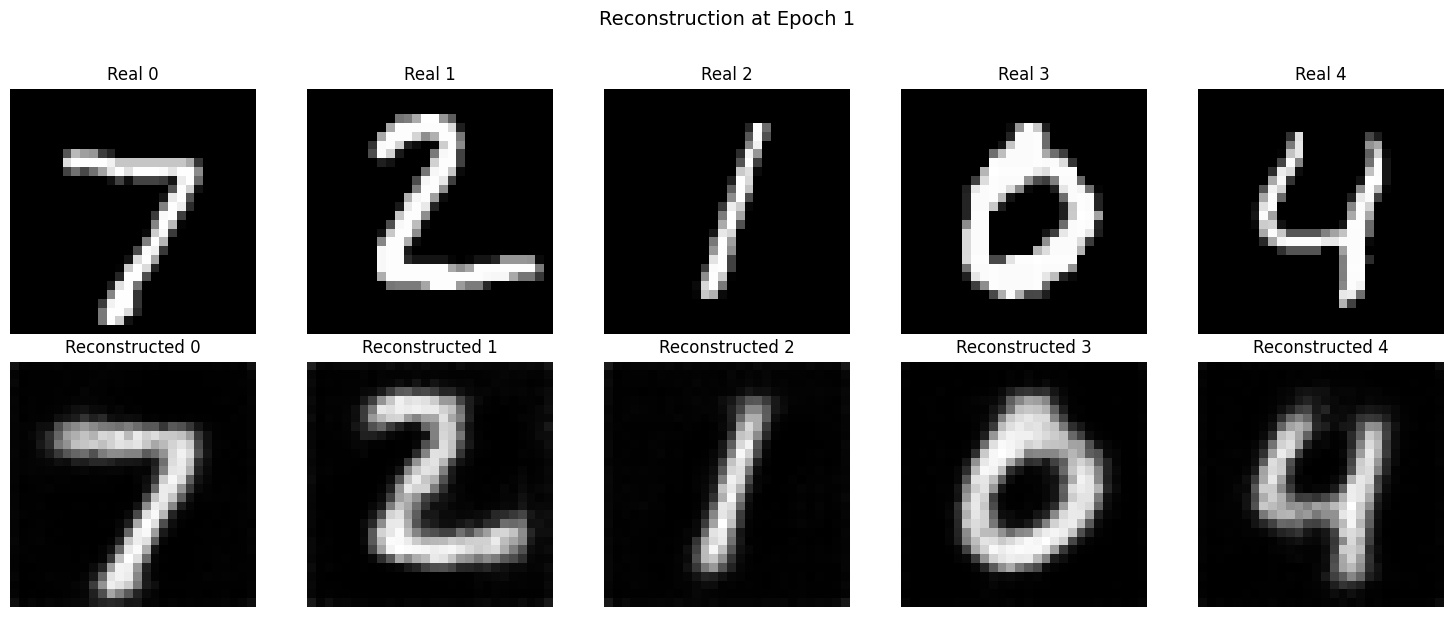

Epoch 2/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 4/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 5/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 5/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 6/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 6/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

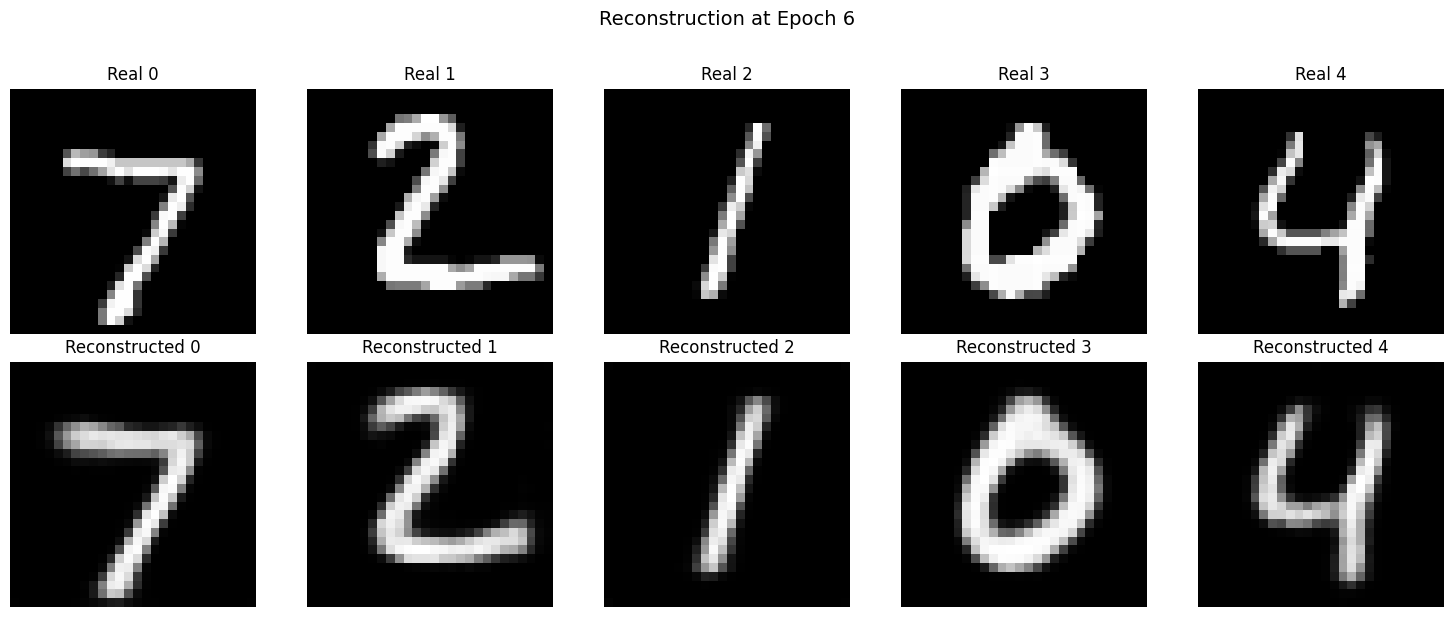

Epoch 7/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 7/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 8/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 8/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 9/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 9/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 10/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 10/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 11/11 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 11/11 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

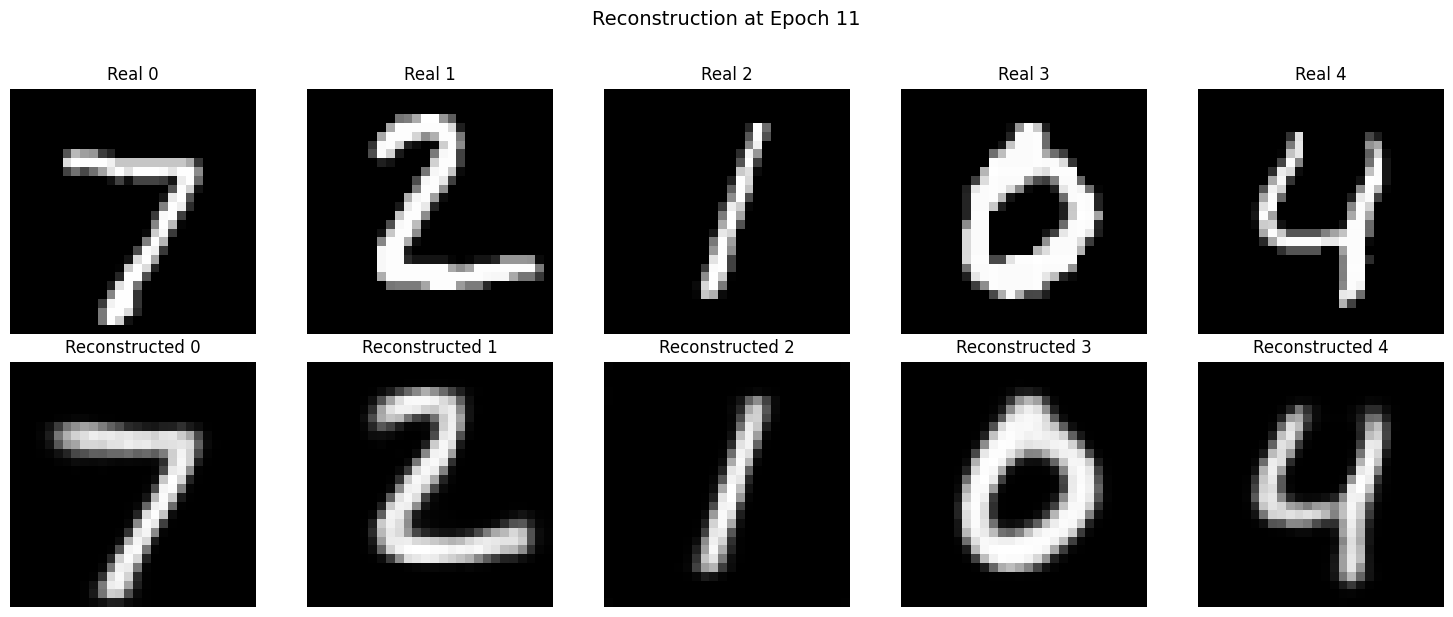

In [27]:
train_losses, val_losses = train_autoencoder(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer,
    scheduler=lr_scheduler,
    loss_func=criterion,
    device=device,
    epochs=11,
    visualize_every=5
)

In [28]:
def plot_losses(train_losses, val_losses=None):
  epochs = range(1, len(train_losses) + 1)

  plt.figure(figsize=(9, 5))
  plt.plot(
      epochs,
      train_losses,
      label="Train Loss",
      color="#1f77b4",
      linewidth=2,
      marker="o",
      markersize=4,
  )

  if val_losses is not None:
    plt.plot(
        epochs,
        val_losses,
        label="Val Loss",
        color="#ff7f0e",
        linewidth=2,
        marker="s",
        markersize=4,
    )

  plt.title("Динамика Loss по эпохам", fontsize=13, fontweight="bold")
  plt.xlabel("Эпоха", fontsize=11)
  plt.ylabel("Loss", fontsize=11)
  plt.xticks(epochs)
  plt.grid(True, linestyle="--", alpha=0.6)
  plt.legend(frameon=True, fontsize=11)
  plt.tight_layout()
  plt.show()

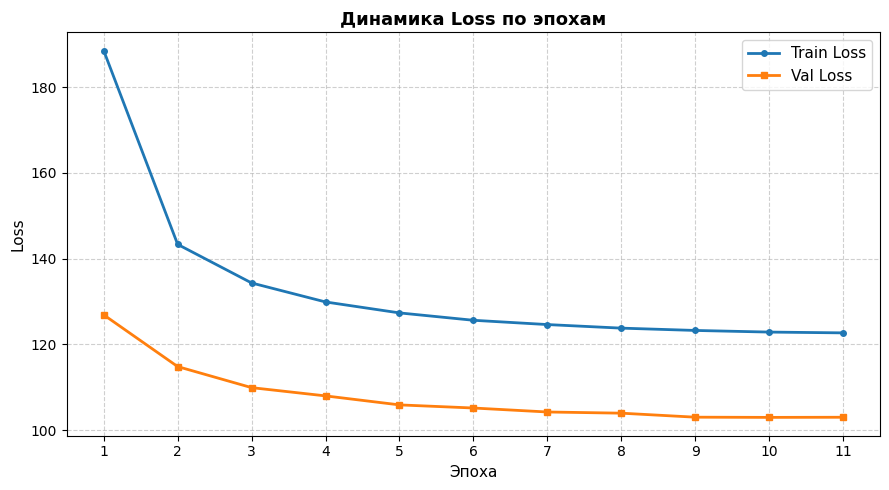

In [29]:
plot_losses(train_losses, val_losses)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

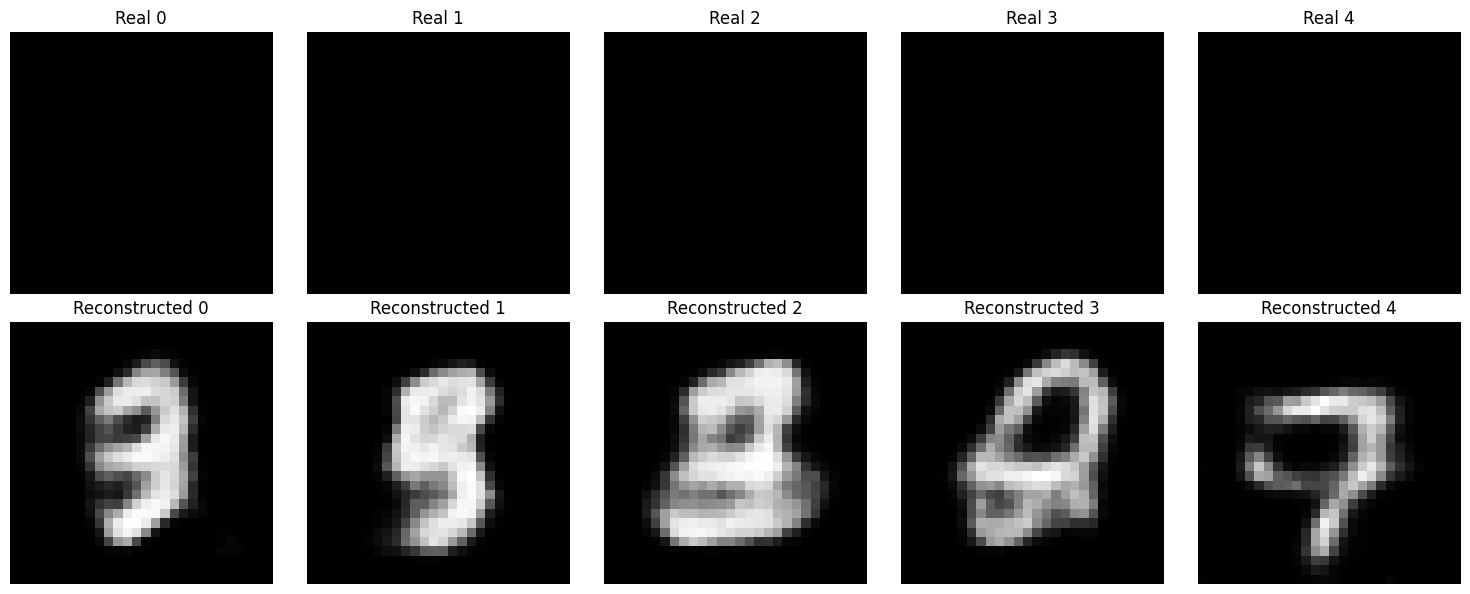

In [30]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = torch.normal(0, 1, (10, dim_code)).to(device)

output = model.module.decode(z)
plot_reconstruction(torch.ones(10, 1, 28, 28), output)

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [40]:
test_data = test_dataset.data.unsqueeze(1).to(device).float() / 255
model.eval()
mu, logsigma, _ = model(test_data)

In [42]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z2d = tsne.fit_transform(mu.detach().cpu())

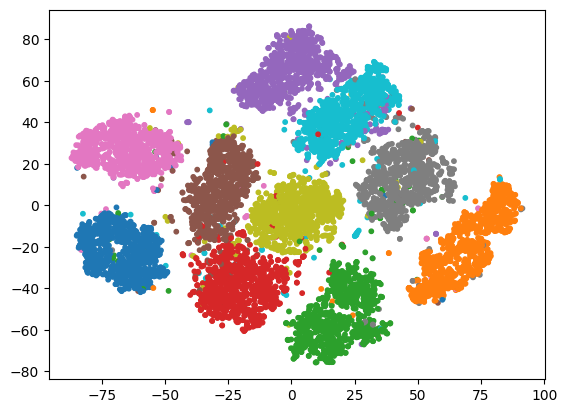

In [52]:
plt.scatter(z2d[:, 0], z2d[:, 1], c=test_dataset.targets, cmap="tab10", s=10)

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [53]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, pool=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool = pool

    def forward(self, x):
        x = self.block(x)
        return F.max_pool2d(x, 2) if self.pool else x

class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, padding=1, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, 
                               padding=padding, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [59]:
class CVAE(nn.Module):
    def __init__(self, in_channels, dim_code, num_classes):
        super().__init__()
        self.dim_code = dim_code
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64, pool=False),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(7 * 7 * 64 + num_classes, dim_code)
        self.fc_logsigma = nn.Linear(7 * 7 * 64 + num_classes, dim_code)

        self.decoder = nn.Sequential(
            TransposeConvBlock(64, 32),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, padding=1, stride=2, bias=True),
            nn.Sigmoid()
        )
        self.decoder_linear = nn.Linear(dim_code + num_classes, 7 * 7 * 64)

    def encode(self, x, class_num):
        x = self.encoder(x)
        ohe = torch.nn.functional.one_hot(class_num.view(-1), self.num_classes).float()
        x = torch.cat([x, ohe], dim=1)
        
        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, class_num):
        ohe = torch.nn.functional.one_hot(class_num.view(-1), self.num_classes).float()
        z = torch.cat([z, ohe], dim=1)

        z = self.decoder_linear(z).view(-1, 64, 7, 7)
        reconstruction = self.decoder(z)

        return reconstruction

    def forward(self, x, class_num):
        mu, logsigma, _ = self.encode(x, class_num)
        sample = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(sample, class_num)
        
        return mu, logsigma, reconstruction

In [65]:
def train_autoencoder(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_func,
    device,
    epochs=20,
    visualize_every=5,
):
  train_losses = []
  val_losses = []

  for _e in range(epochs):
    # --- Обучение ---
    model.train()
    train_bar = tqdm(
        train_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Train]"
    )
    total_train_loss = 0.0

    for images, labels in train_bar:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      mu, logsigma, predict = model(images, labels)
      loss = loss_func(images, mu, logsigma, predict)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item() * images.size(0)
      train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- Валидация ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
      val_bar = tqdm(
          val_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Val]"
      )
      for i, (images, labels) in enumerate(val_bar):
        images, labels = images.to(device), labels.to(device)
        mu, logsigma, predict = model(images, labels)
        loss = loss_func(images, mu, logsigma, predict)

        total_val_loss += loss.item() * images.size(0)
        val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        if _e % visualize_every == 0 and i == 0:
          plot_reconstruction(images, predict, epoch=_e + 1)

    epoch_train_loss = total_train_loss / len(train_loader.dataset)
    epoch_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --- Шаг планировщика в конце эпохи ---
    if scheduler is not None:
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(epoch_val_loss)  # передаем валидационный лосс
      elif not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step()

  return train_losses, val_losses

In [66]:
dim_code=64

Train on 2 GPUs


Epoch 1/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

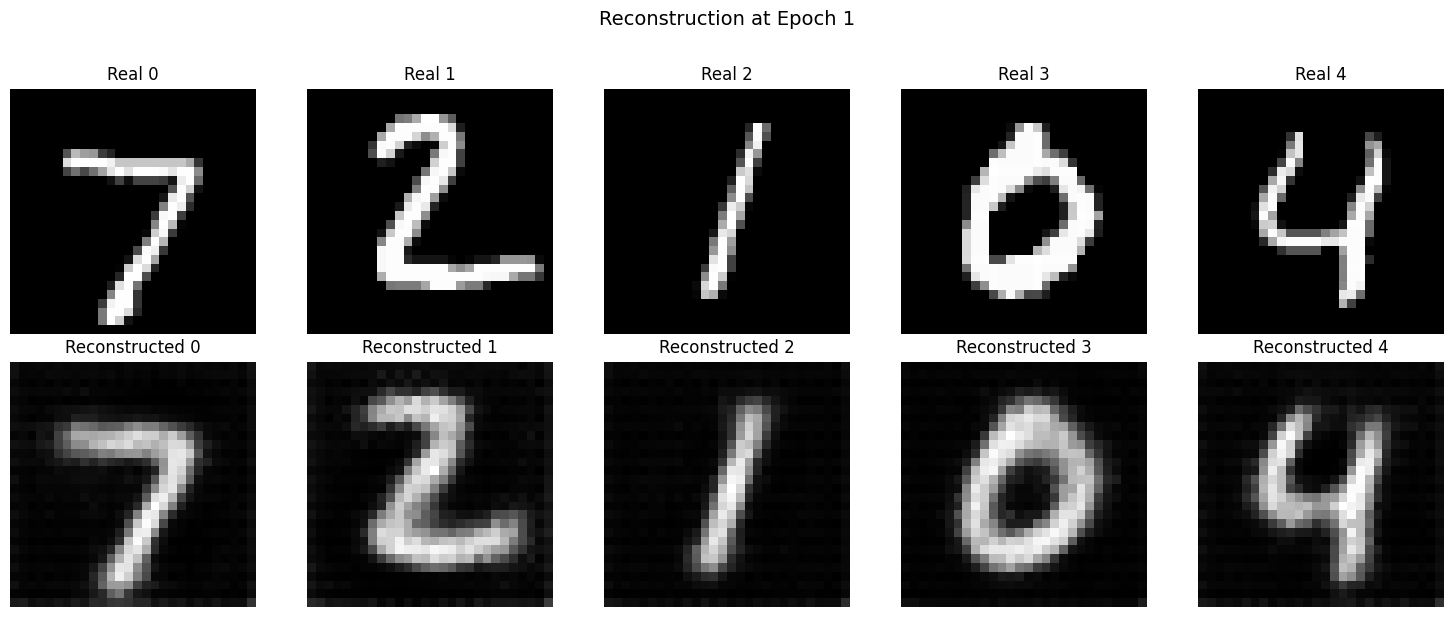

Epoch 2/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x789f043cb240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


Epoch 2/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 4/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 5/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 5/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 6/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 6/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

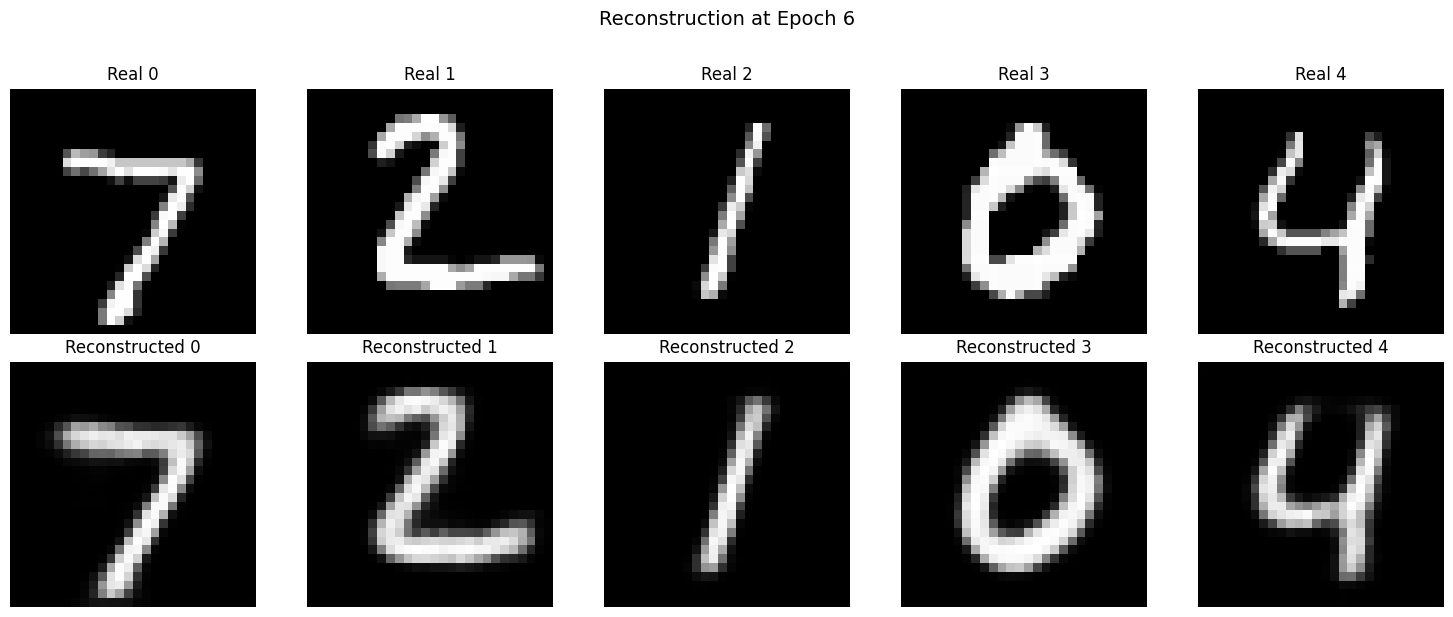

Epoch 7/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 7/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 8/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 8/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 9/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 9/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 10/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 10/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 11/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 11/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

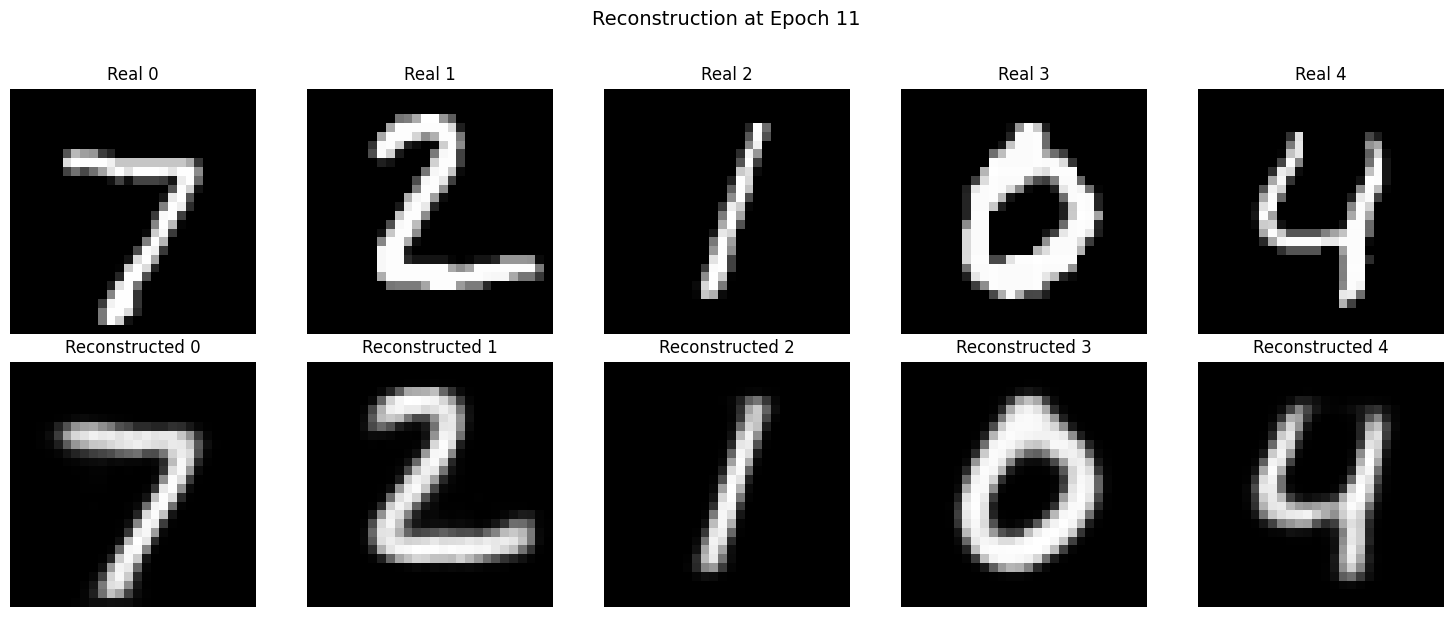

Epoch 12/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 12/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 13/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 13/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 14/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 14/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 15/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 15/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 16/16 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 16/16 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

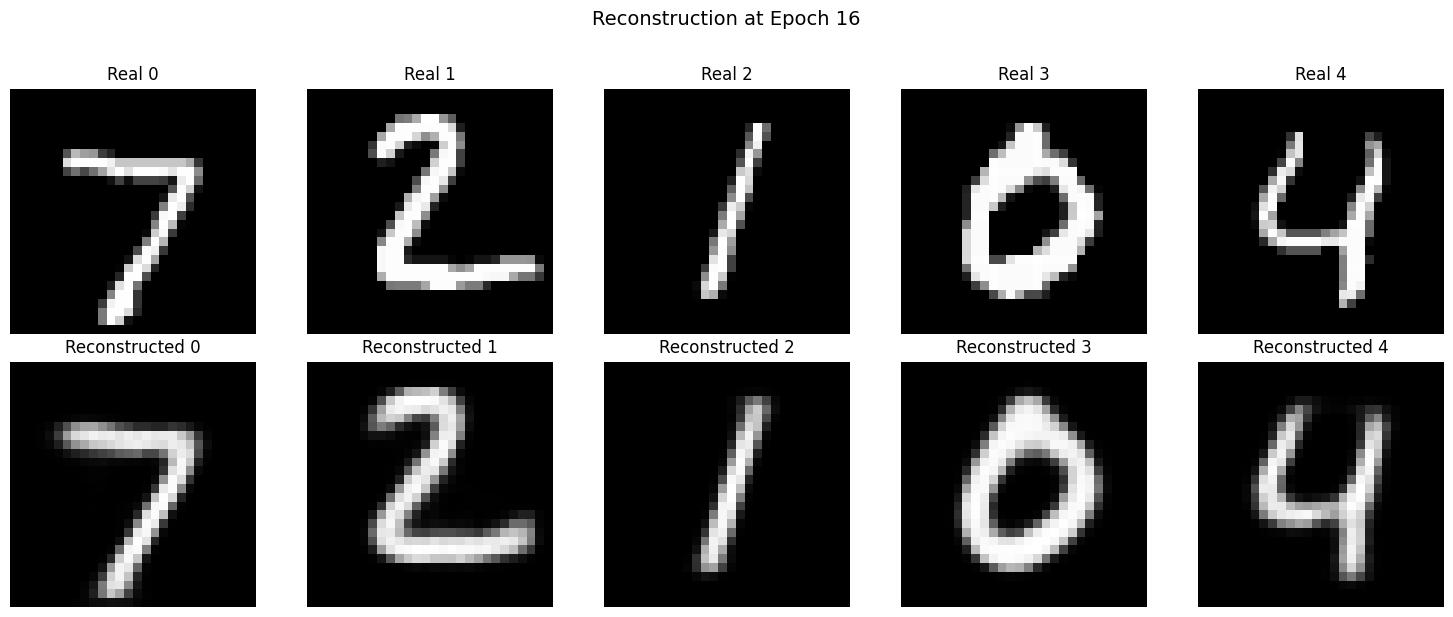

In [67]:
criterion = loss_vae
model = CVAE(in_channels=1, dim_code=dim_code, num_classes=10).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=16, eta_min=1e-5)

if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

train_losses, val_losses = train_autoencoder(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer,
    scheduler=lr_scheduler,
    loss_func=criterion,
    device=device,
    epochs=16,
    visualize_every=5
)

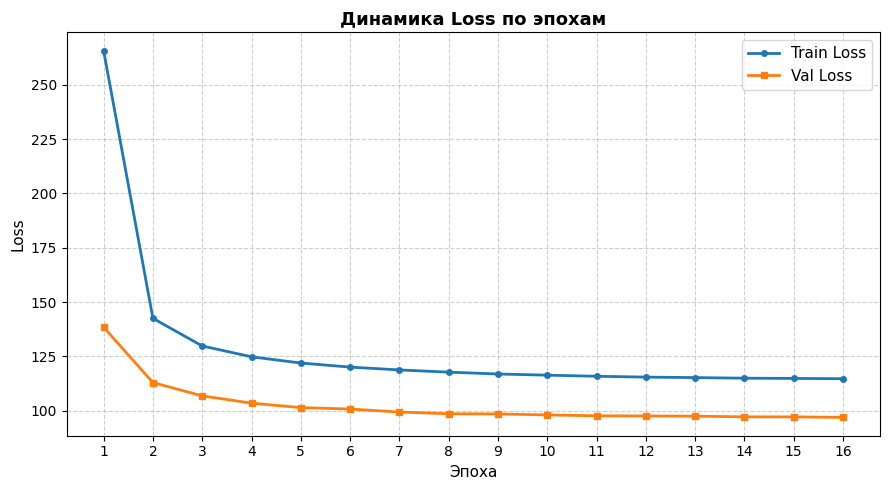

In [68]:
plot_losses(train_losses, val_losses)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

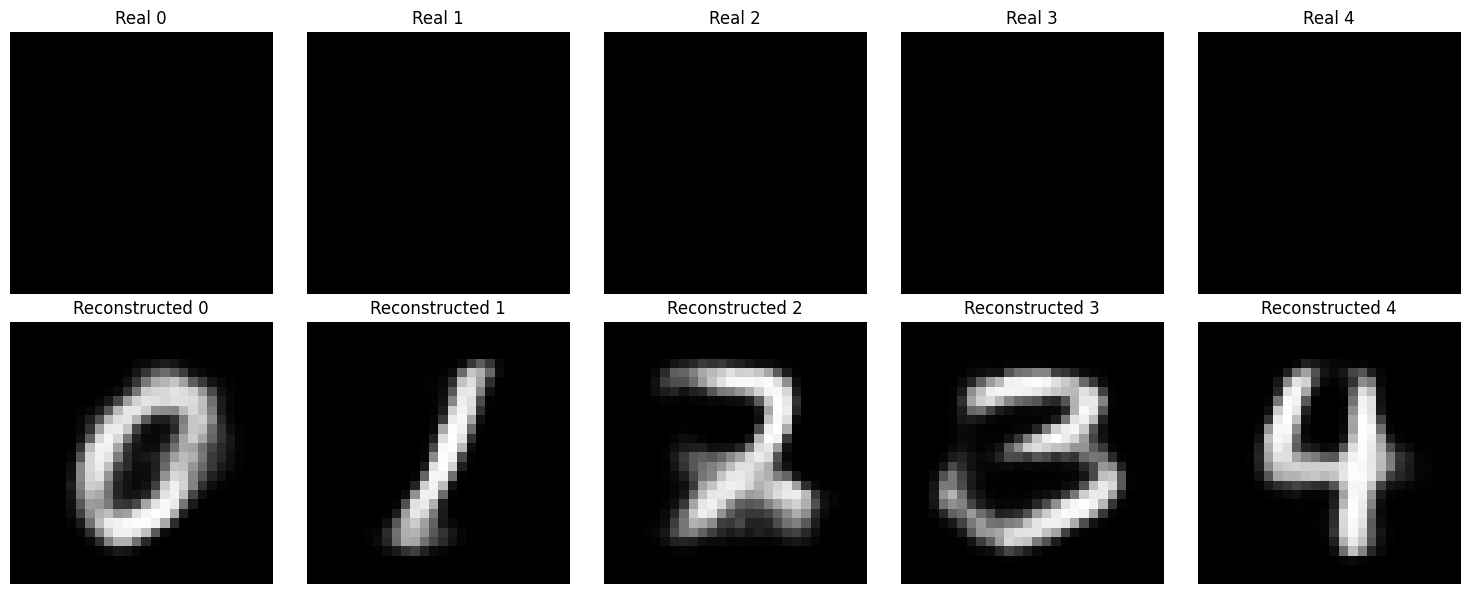

In [105]:
z = torch.randn(5, 64).to(device)
labels = torch.arange(5).to(device)
with torch.no_grad():
    predict = model.module.decode(z, labels)
plot_reconstruction(torch.ones(5, 1, 28, 28), predict)

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [89]:
test_data = test_dataset.data.unsqueeze(1).float().to(device)
labels = test_dataset.targets.to(device)
model.eval()
mu, logsigma, _ = model(test_data, labels)
mu.shape

torch.Size([10000, 64])

In [91]:
from sklearn.manifold import TSNE

tsne = TSNE()
z_cvae = tsne.fit_transform(mu.detach().cpu())

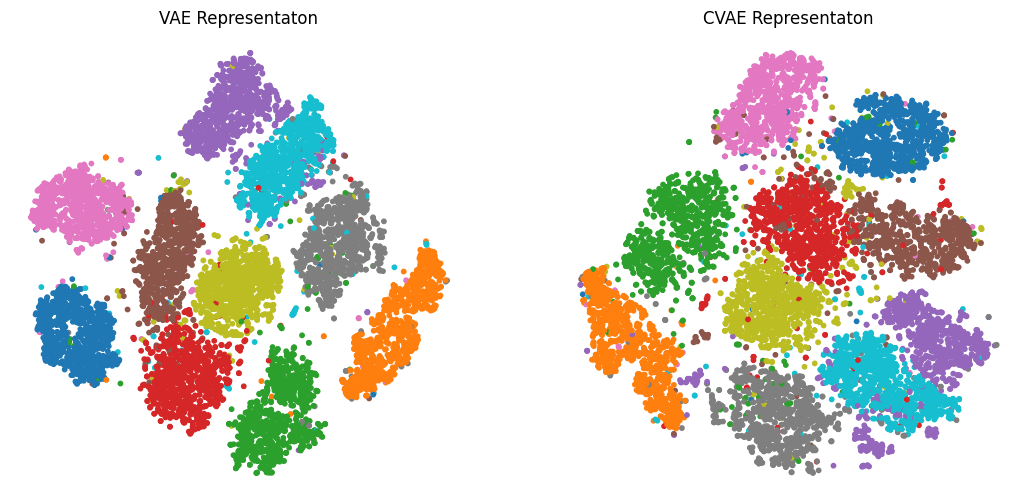

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(z2d[:, 0], z2d[:, 1], cmap="tab10", c=labels.cpu(), s=10)
axes[0].set_title("VAE Representaton")
axes[0].axis('off')

axes[1].scatter(z_cvae[:, 0], z_cvae[:, 1], cmap="tab10", c=labels.cpu(), s=10)
axes[1].set_title("CVAE Representaton")
axes[1].axis('off');

### Практический вывод: Интерпретация латентного пространства

* **В обычном VAE:** координаты $z$ напрямую определяют саму цифру. Сдвиг вдоль оси в скрытом пространстве приводит к изменению класса объекта (например, трансформация формы из цифры 3 в цифру 8).
* **В CVAE:** координаты $z$ отвечают исключительно за *стиль* изображения, тогда как семантический класс объекта жестко задается внешним условием $y$. Если зафиксировать случайный вектор $z_0$ и последовательно перебирать метку класса от 0 до 9, модель синтезирует все 10 цифр, выполненных **одним и тем же почерком** (с идентичным наклоном штриха, толщиной линий и масштабом).

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [142]:
images = images / 255.

In [182]:
noise_factor = 0.15
noise = np.random.normal(loc=0.0, scale=noise_factor, size=images.shape)
images_noisy = np.clip(images + noise, 0.0, 1.0)

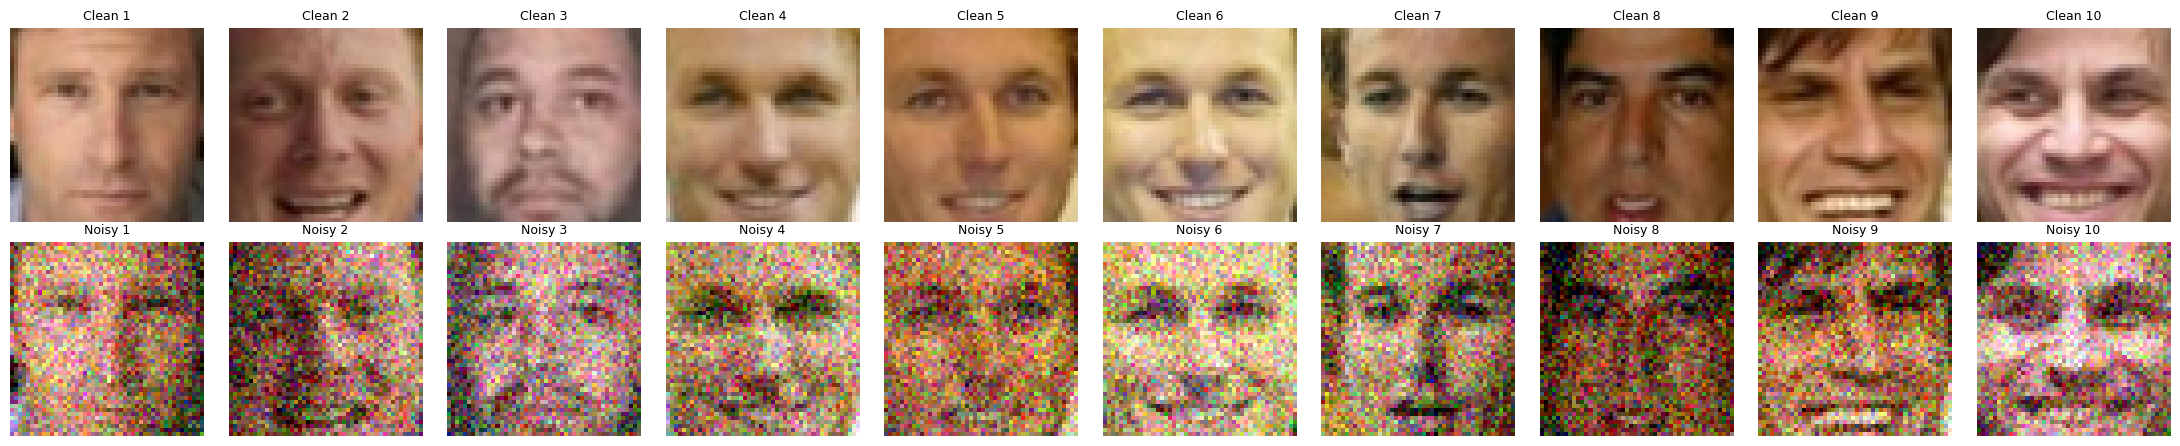

In [144]:
num_samples = min(10, len(images))
fig, axes = plt.subplots(
    2, num_samples, figsize=(2.2 * num_samples, 4.5)
)  #[cite: 1]

for i in range(num_samples):
  # Верхняя строка: Чистые картинки (таргет для Denoising)
  axes[0, i].imshow(images[i])
  axes[0, i].set_title(f"Clean {i+1}", fontsize=9)
  axes[0, i].axis("off")  #[cite: 1]

  # Нижняя строка: Зашумленные картинки (вход в модель)
  axes[1, i].imshow(images_noisy[i])
  axes[1, i].set_title(f"Noisy {i+1}", fontsize=9)
  axes[1, i].axis("off")  #[cite: 1]

plt.tight_layout()  #[cite: 1]
plt.show()

In [145]:
from sklearn.model_selection import train_test_split

train_images_noisy, val_images_noisy, train_attrs, val_attrs = train_test_split(images_noisy, attrs, test_size=0.2)
train_images_noisy = torch.from_numpy(train_images_noisy).permute(0, 3, 1, 2).float() / 255.0
val_images_noisy = torch.from_numpy(val_images_noisy).permute(0, 3, 1, 2).float() / 255.0

In [240]:
train_loader = torch.utils.data.DataLoader(train_images.float(), batch_size=512, shuffle=True, 
                                           num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_images.float(), batch_size=256, shuffle=False, 
                                           num_workers=2, pin_memory=True, persistent_workers=True)

### UNet AE

In [216]:
class DoubleConv(nn.Module):
  """Двойной свёрточный блок: [Conv -> BN -> ReLU] x 2."""

  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.net(x)


class DownBlock(nn.Module):
  """Спуск: MaxPool2d -> DoubleConv."""

  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels)

  def forward(self, x):
    x = self.pool(x)
    return self.conv(x)


class UpBlock(nn.Module):
  """Подъём: ConvTranspose2d -> Конкатенация со skip-connection -> DoubleConv."""

  def __init__(self, in_channels, out_channels):
    super().__init__()
    # in_channels уменьшается в 2 раза через апсемплинг
    self.up = nn.ConvTranspose2d(
        in_channels, out_channels, kernel_size=2, stride=2
    )
    # После torch.cat каналов будет out_channels (skip) + out_channels (up) = 2 * out_channels
    self.conv = DoubleConv(out_channels * 2, out_channels)

  def forward(self, x, skip):
    x = self.up(x)

    # Если размеры x и skip случайно разошлись из-за нечетных H/W
    if x.shape != skip.shape:
      diff_y = skip.size(2) - x.size(2)
      diff_x = skip.size(3) - x.size(3)
      x = F.pad(
          x,
          [
              diff_x // 2,
              diff_x - diff_x // 2,
              diff_y // 2,
              diff_y - diff_y // 2,
          ],
      )

    x = torch.cat([skip, x], dim=1)
    return self.conv(x)


class DenoisingUNet(nn.Module):

  def __init__(self, in_channels=3, out_channels=3, base_channels=32):
    super().__init__()
    # Энкодер (3 уровня сжатия идеальны для разрешения 48x48: 48 -> 24 -> 12 -> 6)
    self.inc = DoubleConv(in_channels, base_channels)
    self.down1 = DownBlock(base_channels, base_channels * 2)  # 24x24
    self.down2 = DownBlock(base_channels * 2, base_channels * 4)  # 12x12
    self.down3 = DownBlock(base_channels * 4, base_channels * 8)  # 6x6

    # Bottleneck
    self.bottleneck = DoubleConv(base_channels * 8, base_channels * 8)

    # Декодер
    self.up1 = UpBlock(base_channels * 8, base_channels * 4)  # 12x12
    self.up2 = UpBlock(base_channels * 4, base_channels * 2)  # 24x24
    self.up3 = UpBlock(base_channels * 2, base_channels)  # 48x48

    # Выходная проекция в исходное число каналов
    self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)
    self.activation = nn.Sigmoid()  # гарантирует диапазон пикселей [0.0, 1.0]

  def forward(self, x):
    # Энкодер + сохранение skip-connections
    x1 = self.inc(x)  # [B, 32, 48, 48]
    x2 = self.down1(x1)  # [B, 64, 24, 24]
    x3 = self.down2(x2)  # [B, 128, 12-12]
    x4 = self.down3(x3)  # [B, 256, 6, 6]

    # Bottleneck
    b = self.bottleneck(x4)

    # Декодер со склейкой признаков
    d = self.up1(b, x3)
    d = self.up2(d, x2)
    d = self.up3(d, x1)

    return self.activation(self.out_conv(d))

In [208]:
def plot_denoising_results(
    clean_images, noisy_images, restored_images, num_samples=8
):
  """Отрисовывает 3 строки:

  1 - Исходное чистое изображение 2 - Зашумленное изображение 3 - Результат
  восстановления моделью

  Поддерживает как PyTorch-тензоры [B, C, H, W] или [B, H, W], так и
  NumPy-массивы [B, H, W, C].
  """
  n = min(len(clean_images), num_samples)

  def prepare_img(img):
    # Если на входе тензор PyTorch, переводим в CPU numpy
    if isinstance(img, torch.Tensor):
      img = img.detach().cpu().numpy()

    # Сжатие [1, H, W] -> [H, W] для ч/б картинок
    if img.ndim == 3 and img.shape[0] == 1:
      img = img.squeeze(0)
    # Перевод PyTorch формата [C, H, W] в формат Matplotlib [H, W, C]
    elif img.ndim == 3 and img.shape[0] == 3:
      img = np.transpose(img, (1, 2, 0))

    # Обрезка диапазона [0.0, 1.0] для корректной отрисовки без артефактов
    return np.clip(img, 0.0, 1.0)

  fig, axes = plt.subplots(3, n, figsize=(2.4 * n, 7.5))
  if n == 1:
    axes = axes[:, None]

  row_titles = ["1. Clean Image", "2. Noisy Input", "3. Model Denoised"]

  for i in range(n):
    # Строка 1: Исходная чистая картинка
    img_clean = prepare_img(clean_images[i])
    axes[0, i].imshow(img_clean, cmap="gray" if img_clean.ndim == 2 else None)
    axes[0, i].set_title(f"Sample {i + 1}", fontsize=10)
    axes[0, i].axis("off")

    # Строка 2: Зашумленная картинка
    img_noisy = prepare_img(noisy_images[i])
    axes[1, i].imshow(img_noisy, cmap="gray" if img_noisy.ndim == 2 else None)
    axes[1, i].axis("off")

    # Строка 3: Предсказание модели
    img_restored = prepare_img(restored_images[i])
    axes[2, i].imshow(
        img_restored, cmap="gray" if img_restored.ndim == 2 else None
    )
    axes[2, i].axis("off")

  # Подписи для строк слева
  for row_idx, title in enumerate(row_titles):
    axes[row_idx, 0].text(
        -0.15,
        0.5,
        title,
        transform=axes[row_idx, 0].transAxes,
        fontsize=12,
        fontweight="bold",
        va="center",
        ha="right",
        rotation=90,
    )

  plt.tight_layout()
  plt.show()

In [220]:
def train_denoiser(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_func,
    device,
    epochs=20,
    noise_factor=0.15,
    visualize_every=5,
):
  train_losses = []
  val_losses = []

  for _e in range(epochs):
    # --- Обучение ---
    model.train()
    train_bar = tqdm(
        train_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Train]"
    )
    total_train_loss = 0.0

    for images in train_bar:
      # images — чистый таргет
      images = images.to(device)

      # 1. Генерируем зашумленный входной тензор
      noise = torch.randn_like(images) * noise_factor
      noisy_images = torch.clamp(images + noise, 0.0, 1.0)

      # 2. Прямой проход и оптимизация
      optimizer.zero_grad()
      predict = model(noisy_images)
      loss = loss_func(predict, images)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item() * images.size(0)
      train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- Валидация ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
      val_bar = tqdm(
          val_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Val]"
      )
      for i, images in enumerate(val_bar):
        images = images.to(device)

        noise = torch.randn_like(images) * noise_factor
        noisy_images = torch.clamp(images + noise, 0.0, 1.0)

        predict = model(noisy_images)
        loss = loss_func(predict, images)

        total_val_loss += loss.item() * images.size(0)
        val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        # Визуализируем 3 строки (Clean, Noisy, Pred) на первой пачке валидации
        if _e % visualize_every == 0 and i == 0:
          plot_denoising_results(
              clean_images=images,
              noisy_images=noisy_images,
              restored_images=predict,
              num_samples=8,
          )

    epoch_train_loss = total_train_loss / len(train_loader.dataset)
    epoch_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --- Шаг планировщика ---
    if scheduler is not None:
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(epoch_val_loss)
      elif not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step()

  return train_losses, val_losses

In [221]:
class DenoisingLoss(nn.Module):

  def __init__(self, alpha=0.8):
    super().__init__()
    self.l1 = nn.L1Loss()
    self.mse = nn.MSELoss()
    self.alpha = alpha

  def forward(self, pred, target):
    return self.alpha * self.l1(pred, target) + (1.0 - self.alpha) * self.mse(
        pred, target
    )

Train on 2 GPUs


Epoch 1/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

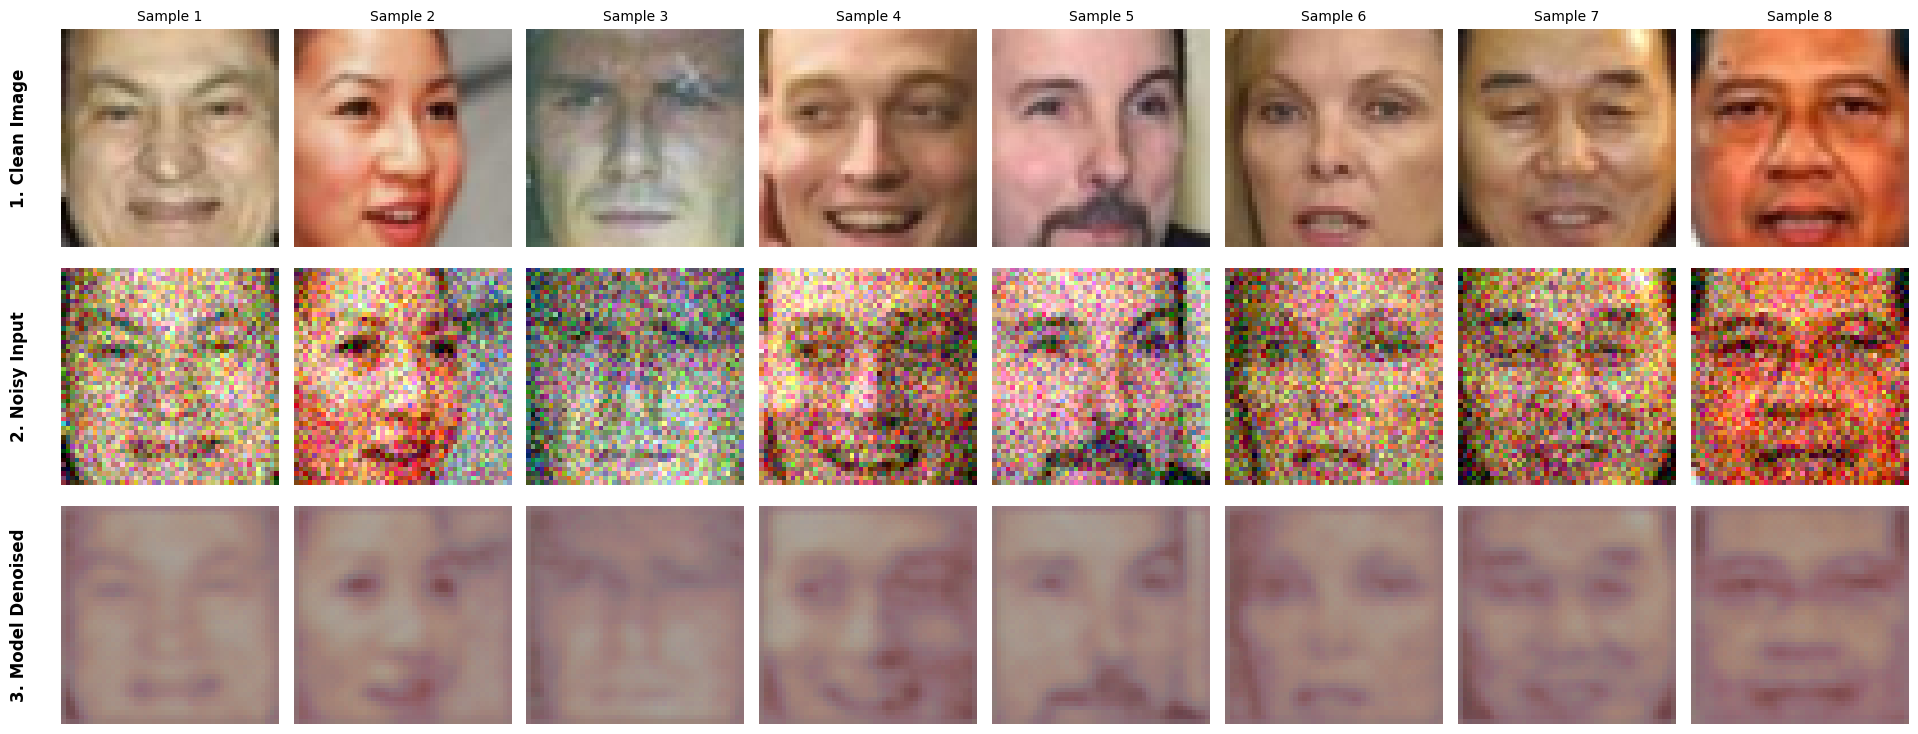

Epoch 2/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 2/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 3/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 4/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 5/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 6/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 6/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

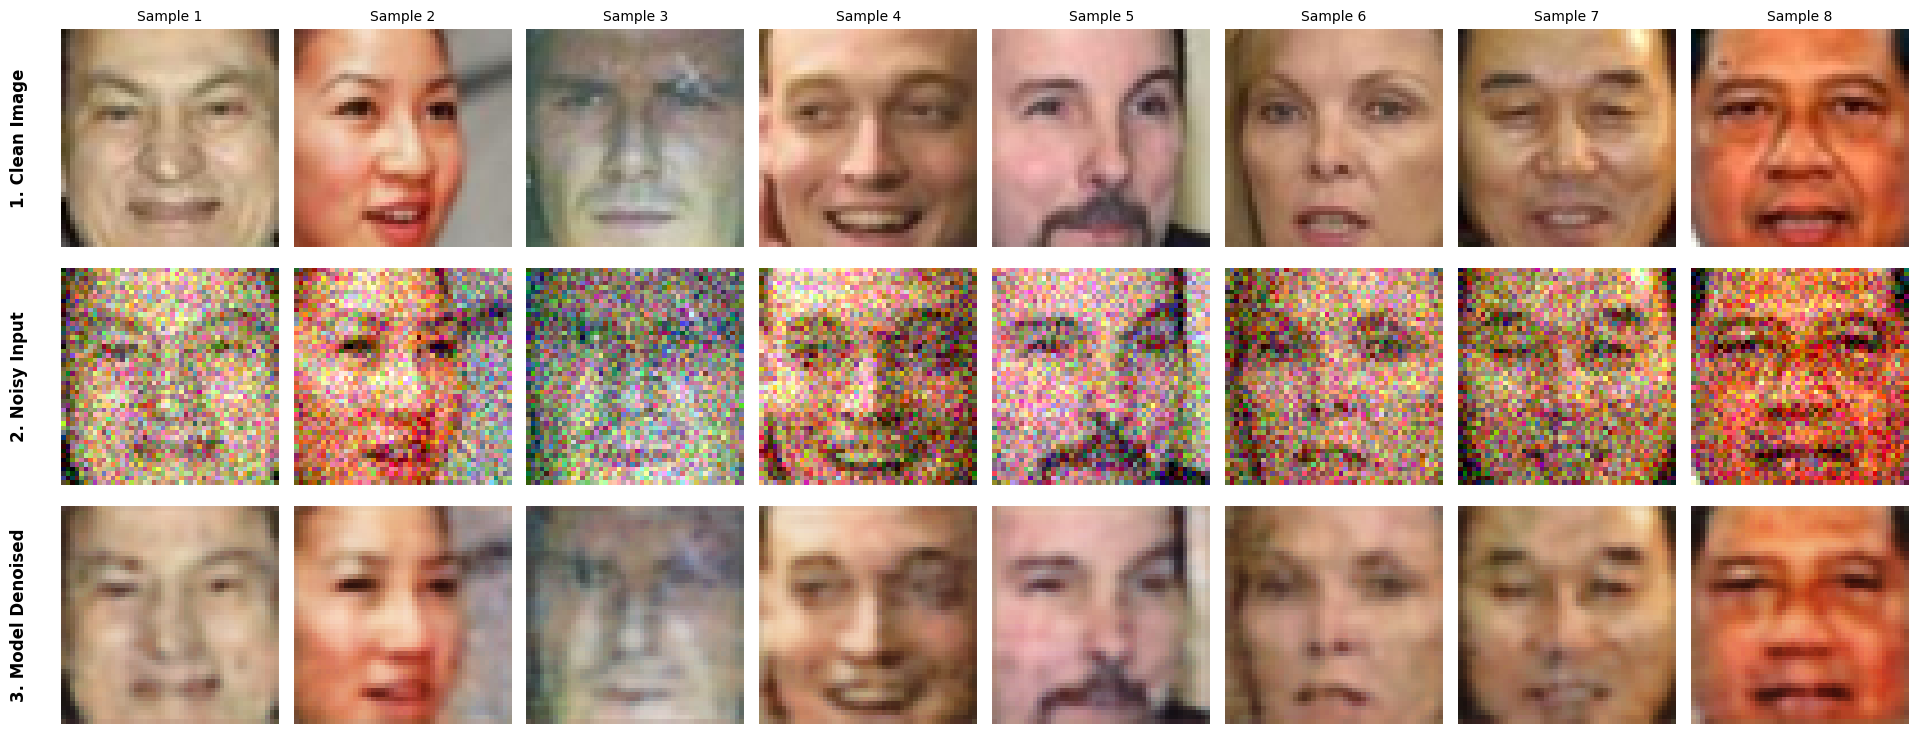

Epoch 7/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 7/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 8/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 8/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 9/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 10/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 11/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 11/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

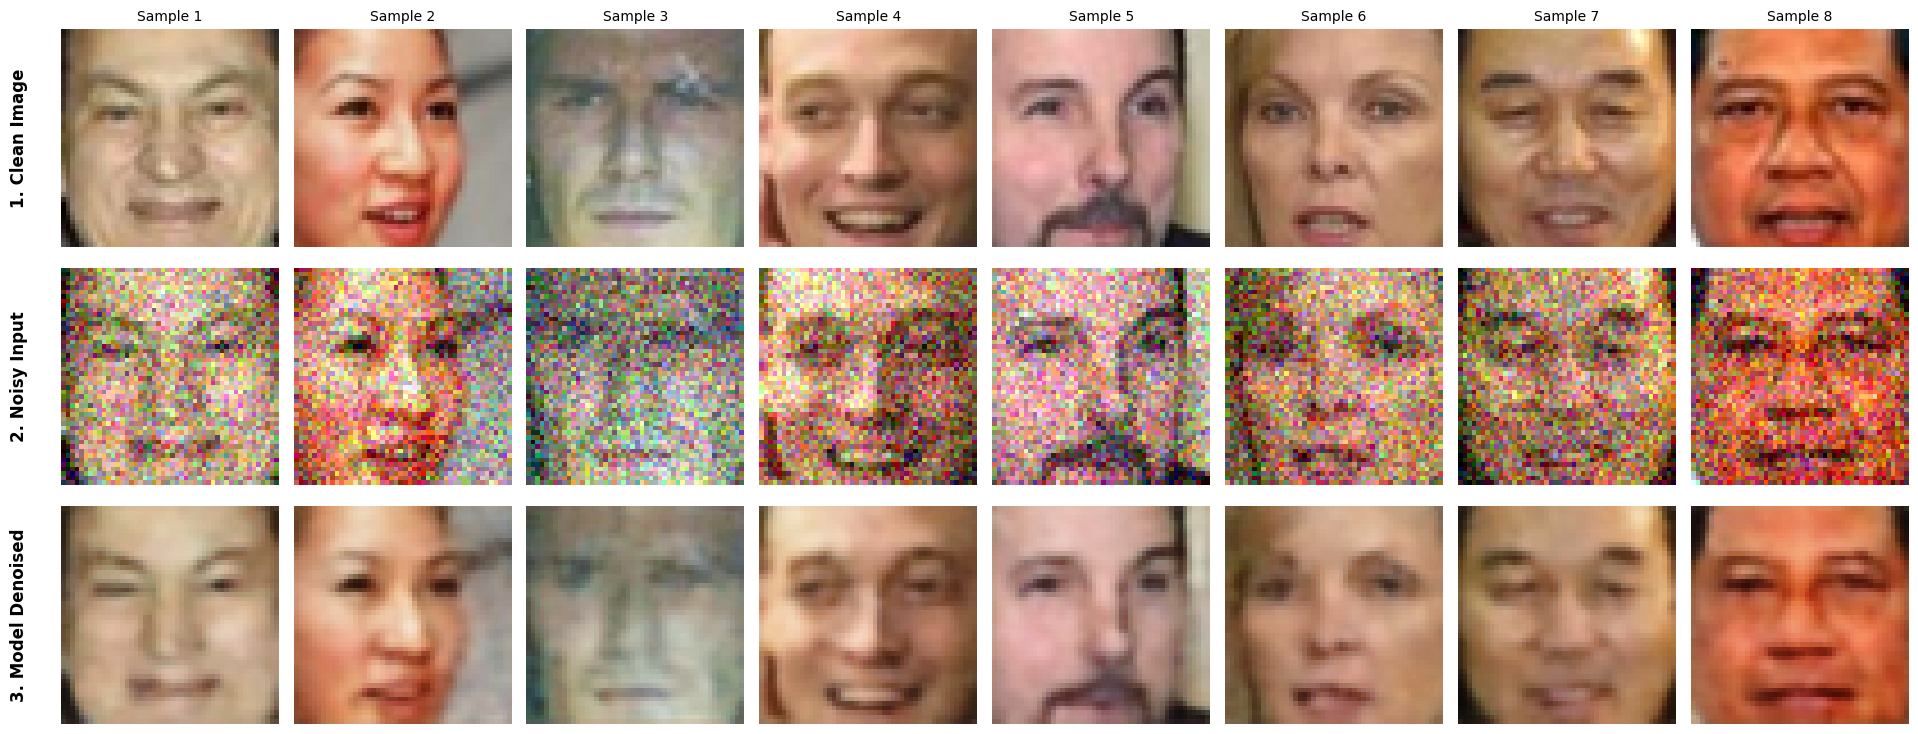

Epoch 12/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 12/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 13/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 13/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 14/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 14/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 15/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 15/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 16/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 16/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

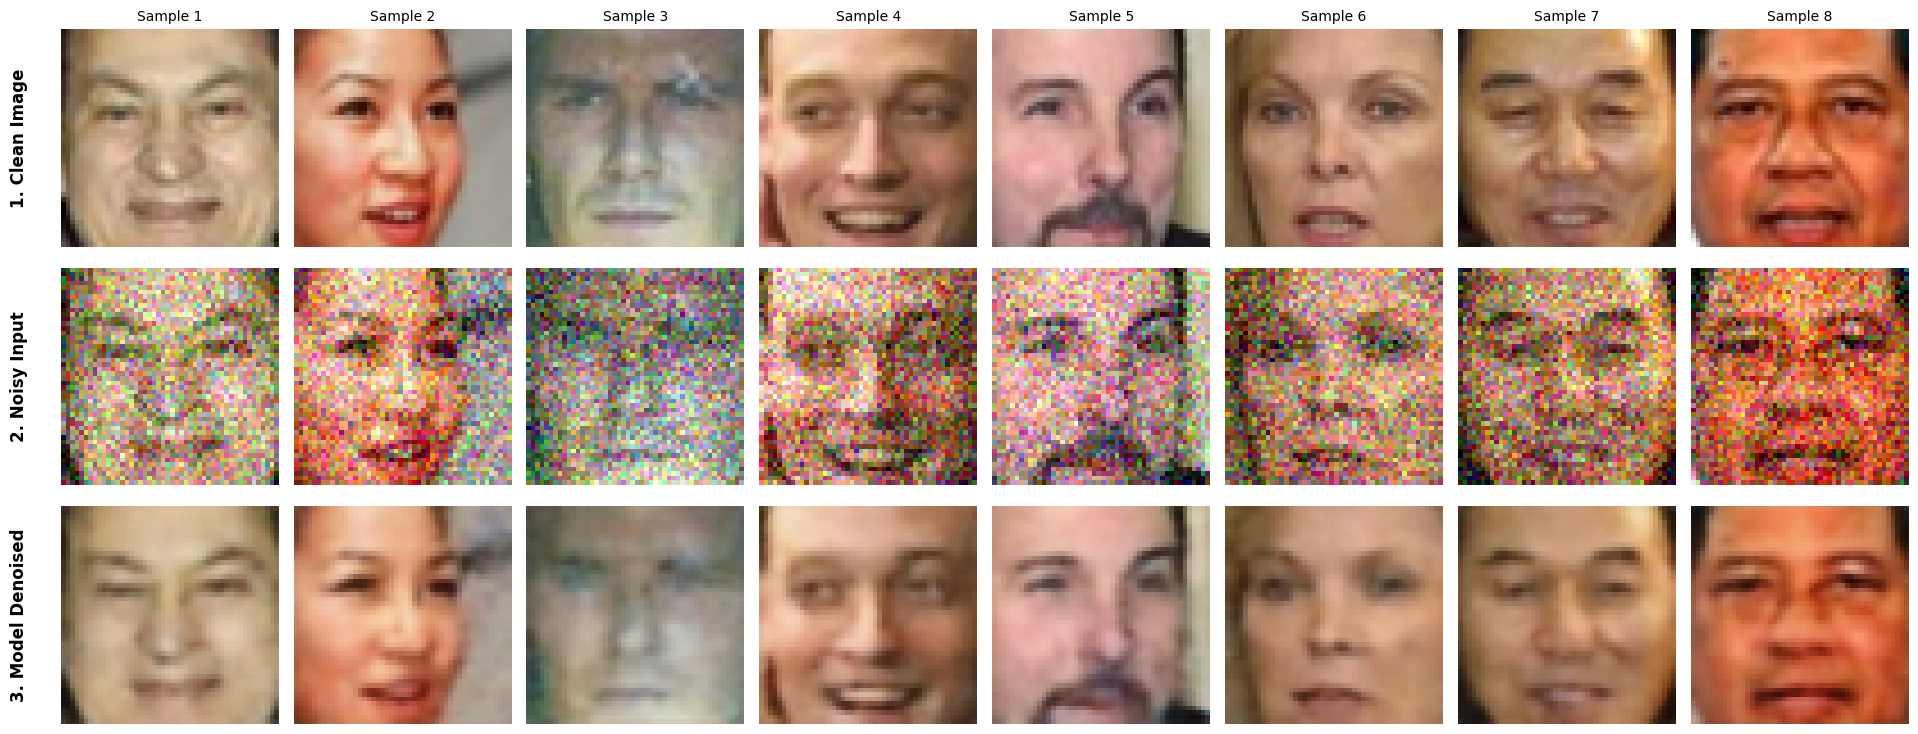

Epoch 17/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 17/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 18/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 18/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 19/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 19/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 20/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 20/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 21/21 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 21/21 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

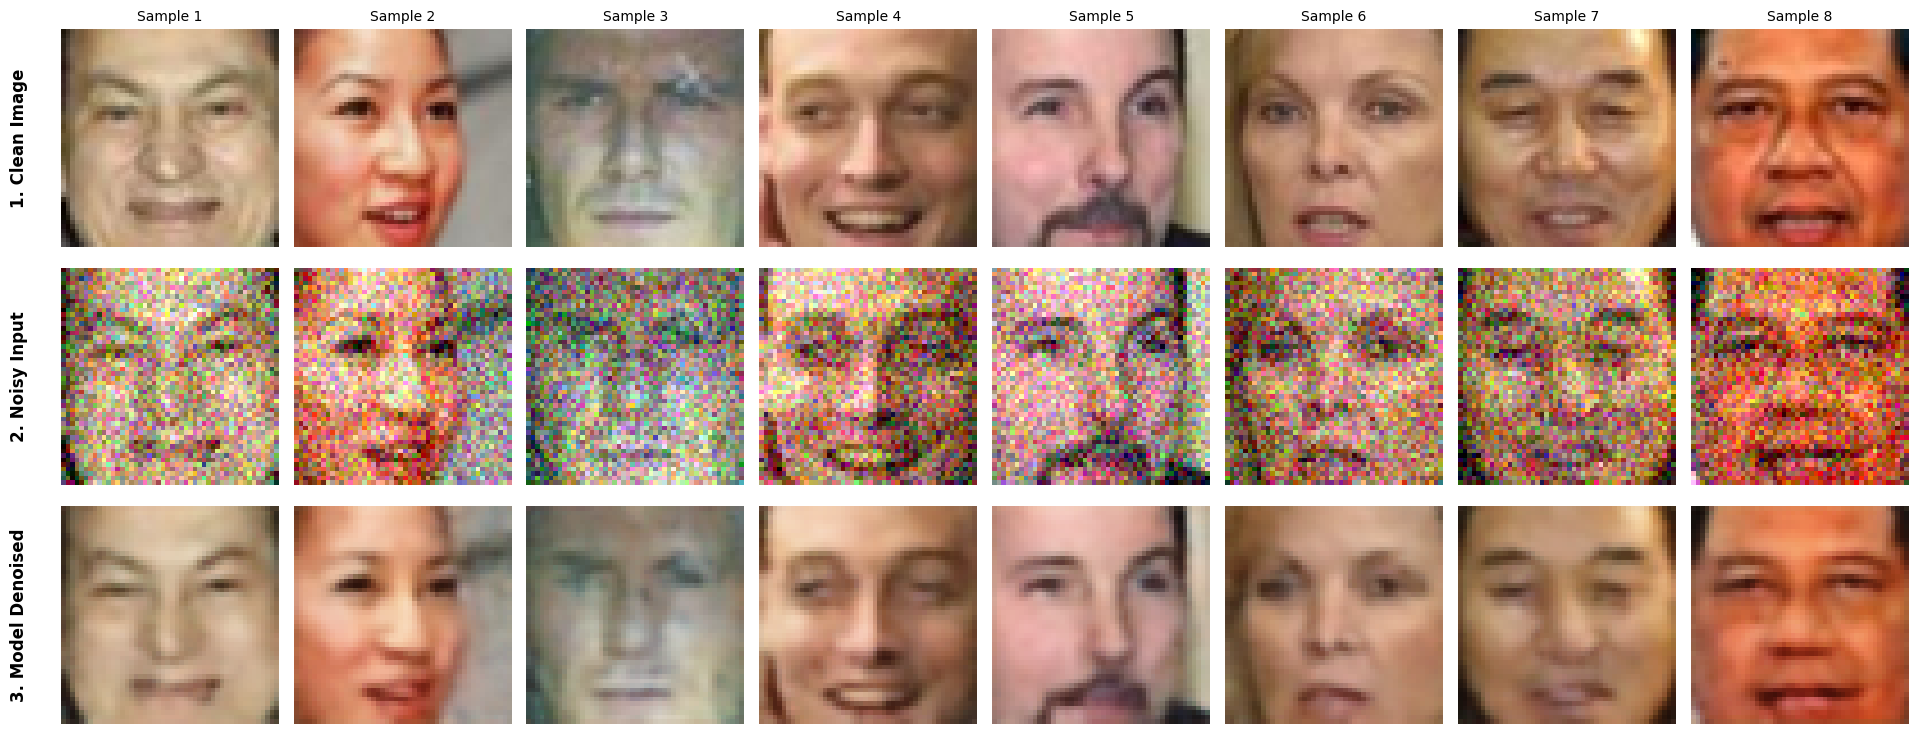

In [224]:
model = DenoisingUNet(in_channels=3, out_channels=3, base_channels=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=21, eta_min=1e-6)
loss_func = DenoisingLoss(alpha=0.7)

if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

train_losses, val_losses = train_denoiser(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_func=loss_func,
    device=device,
    epochs=21,
    visualize_every=5
)

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [244]:
class VAE(nn.Module):

  def __init__(self, in_channels=3, dim_code=128):
    super().__init__()
    self.dim_code = dim_code

    # --- ЭНКОДЕР: 48x48 -> 24x24 -> 12x12 -> 6x6 -> 3x3 ---
    self.encoder_conv = nn.Sequential(
        # 48x48 -> 24x24
        nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2, inplace=True),
        # 24x24 -> 12x12
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),
        # 12x12 -> 6x6
        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),
        # 6x6 -> 3x3
        nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Flatten(),
    )

    # Проекция карт признаков (256 * 3 * 3 = 2304) в mu и logvar
    self.fc_mu = nn.Linear(256 * 3 * 3, dim_code)
    self.fc_logvar = nn.Linear(256 * 3 * 3, dim_code)

    # --- ДЕКОДЕР: dim_code -> 2304 -> 3x3 -> 6x6 -> 12x12 -> 24x24 -> 48x48 ---
    self.decoder_linear = nn.Sequential(
        nn.Linear(dim_code, 256 * 3 * 3), nn.LeakyReLU(0.2, inplace=True)
    )

    self.decoder_conv = nn.Sequential(
        # 3x3 -> 6x6
        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),
        # 6x6 -> 12x12
        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),
        # 12x12 -> 24x24
        nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2, inplace=True),
        # 24x24 -> 48x48
        nn.ConvTranspose2d(
            32, in_channels, kernel_size=4, stride=2, padding=1
        ),
        nn.Sigmoid(),  # Пиксели в интервале [0, 1]
    )

  def encode(self, x):
    h = self.encoder_conv(x)
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    if self.training:
      std = torch.exp(0.5 * logvar)
      eps = torch.randn_like(std)  #
      return mu + eps * std  #
    return mu  # На инференсе и при поиске возвращаем строго mu

  def decode(self, z):
    h = self.decoder_linear(z).view(-1, 256, 3, 3)
    return self.decoder_conv(h)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    recon_x = self.decode(z)
    return mu, logvar, recon_x

In [245]:
def train_autoencoder(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_func,
    device,
    epochs=20,
    visualize_every=5,
):
  train_losses = []
  val_losses = []

  for _e in range(epochs):
    # --- Обучение ---
    model.train()
    train_bar = tqdm(
        train_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Train]"
    )
    total_train_loss = 0.0

    for images in train_bar:
      images = images.to(device)

      optimizer.zero_grad()
      mu, logsigma, predict = model(images)
      loss = loss_func(images, mu, logsigma, predict)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item() * images.size(0)
      train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- Валидация ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
      val_bar = tqdm(
          val_loader, leave=False, desc=f"Epoch {_e+1}/{epochs} [Val]"
      )
      for i, images in enumerate(val_bar):
        images = images.to(device)
        mu, logsigma, predict = model(images)
        loss = loss_func(images, mu, logsigma, predict)

        total_val_loss += loss.item() * images.size(0)
        val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        if _e % visualize_every == 0 and i == 0:
          plot_reconstruction(images, predict, epoch=_e + 1)

    epoch_train_loss = total_train_loss / len(train_loader.dataset)
    epoch_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --- Шаг планировщика в конце эпохи ---
    if scheduler is not None:
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(epoch_val_loss)  # передаем валидационный лосс
      elif not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step()

  return train_losses, val_losses

Train on 2 GPUs


Epoch 1/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

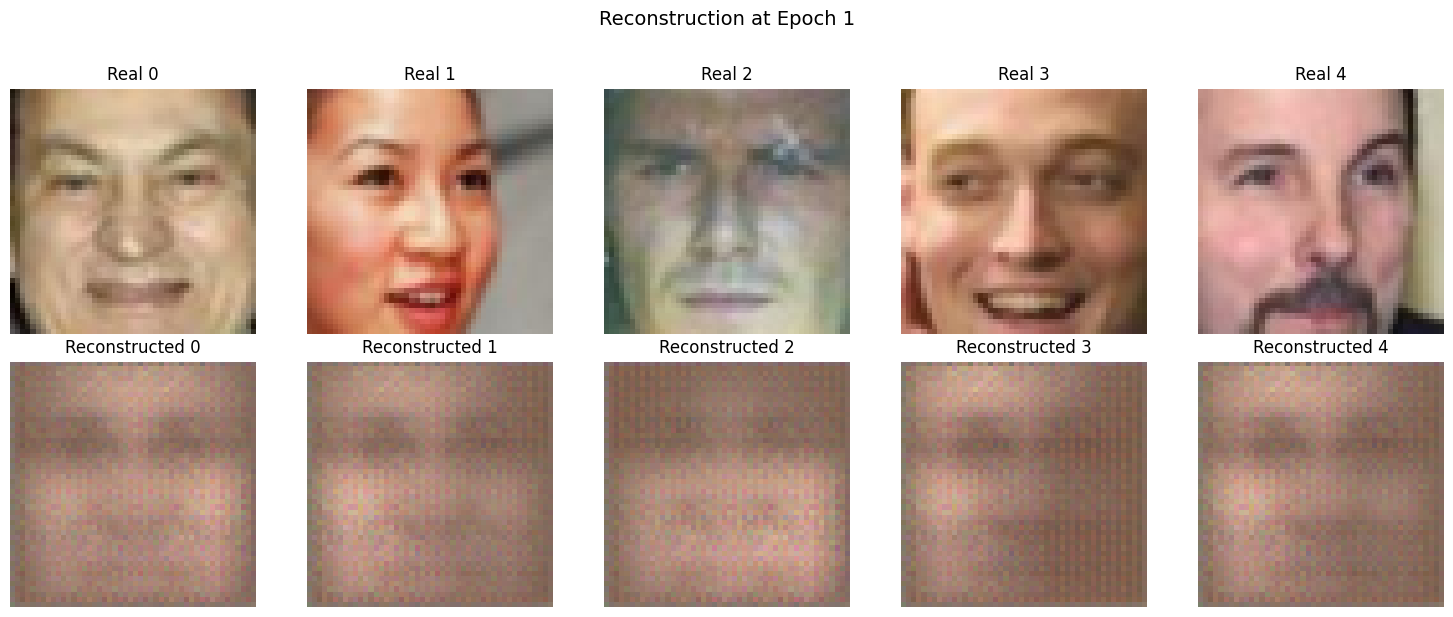

Epoch 2/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 2/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 3/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 4/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 5/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 6/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 6/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

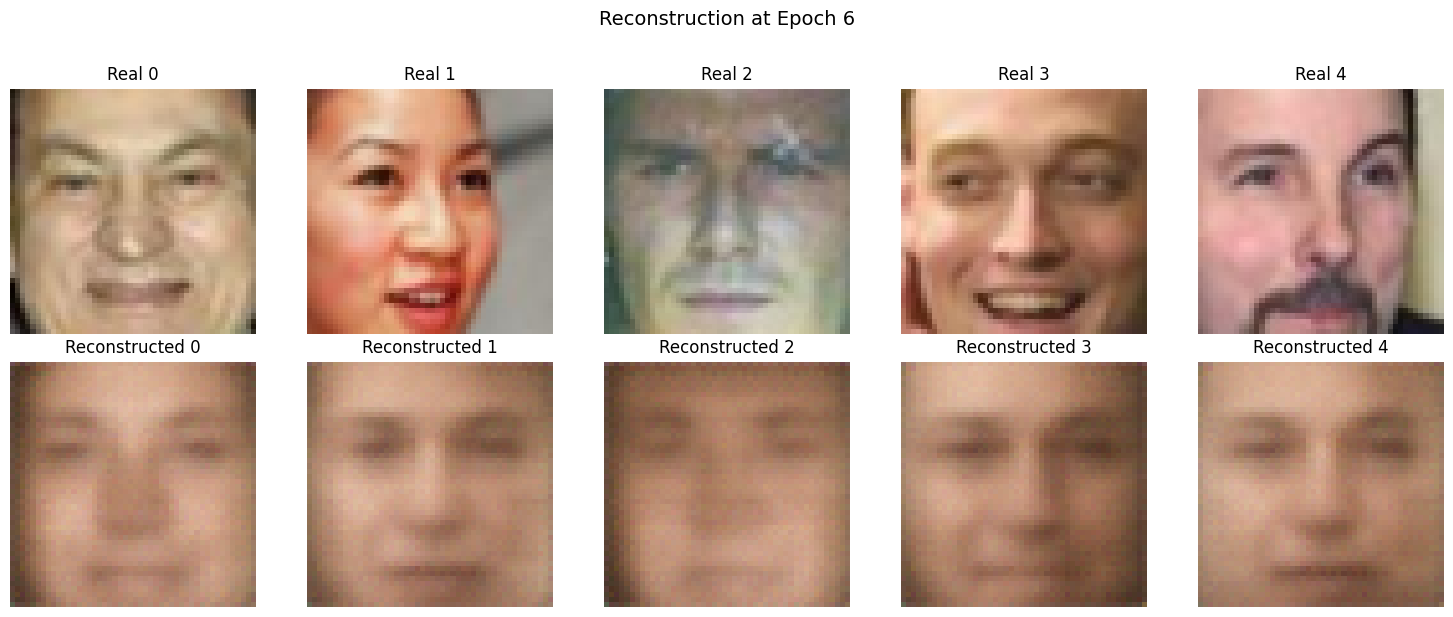

Epoch 7/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 7/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 8/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 8/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 9/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 10/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 11/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 11/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

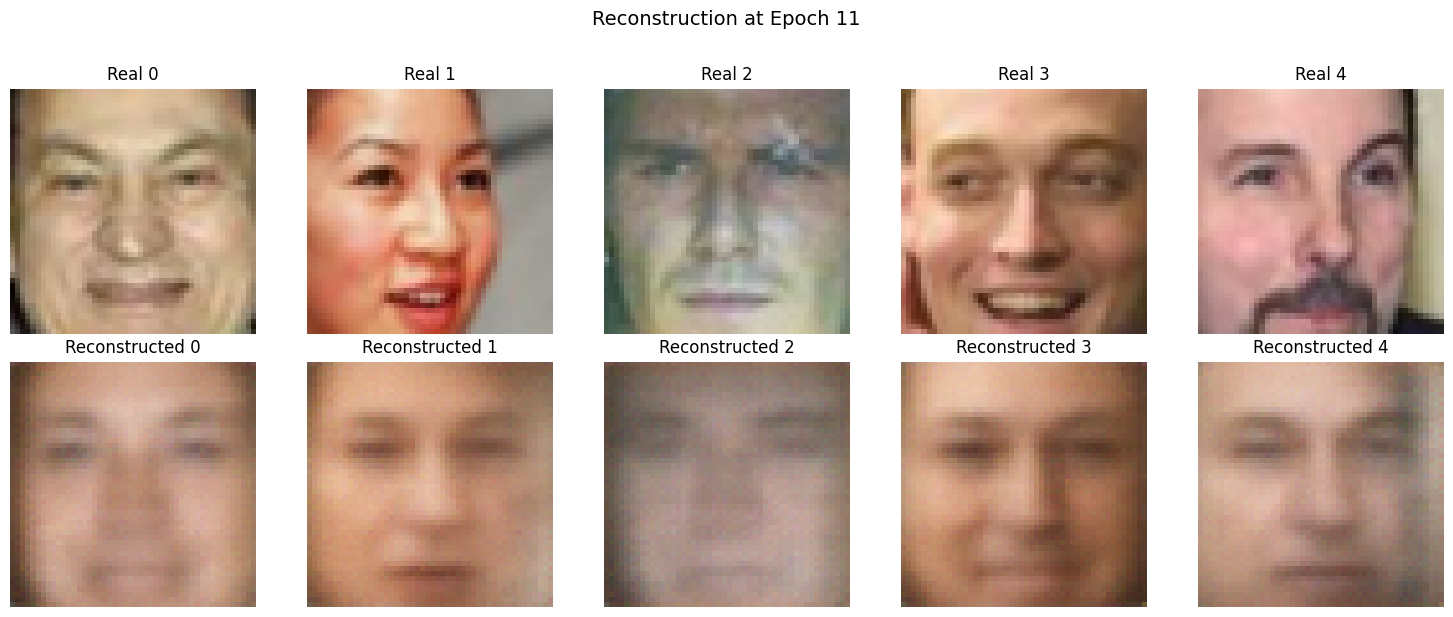

Epoch 12/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 12/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 13/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 13/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 14/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 14/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 15/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 15/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 16/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 16/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

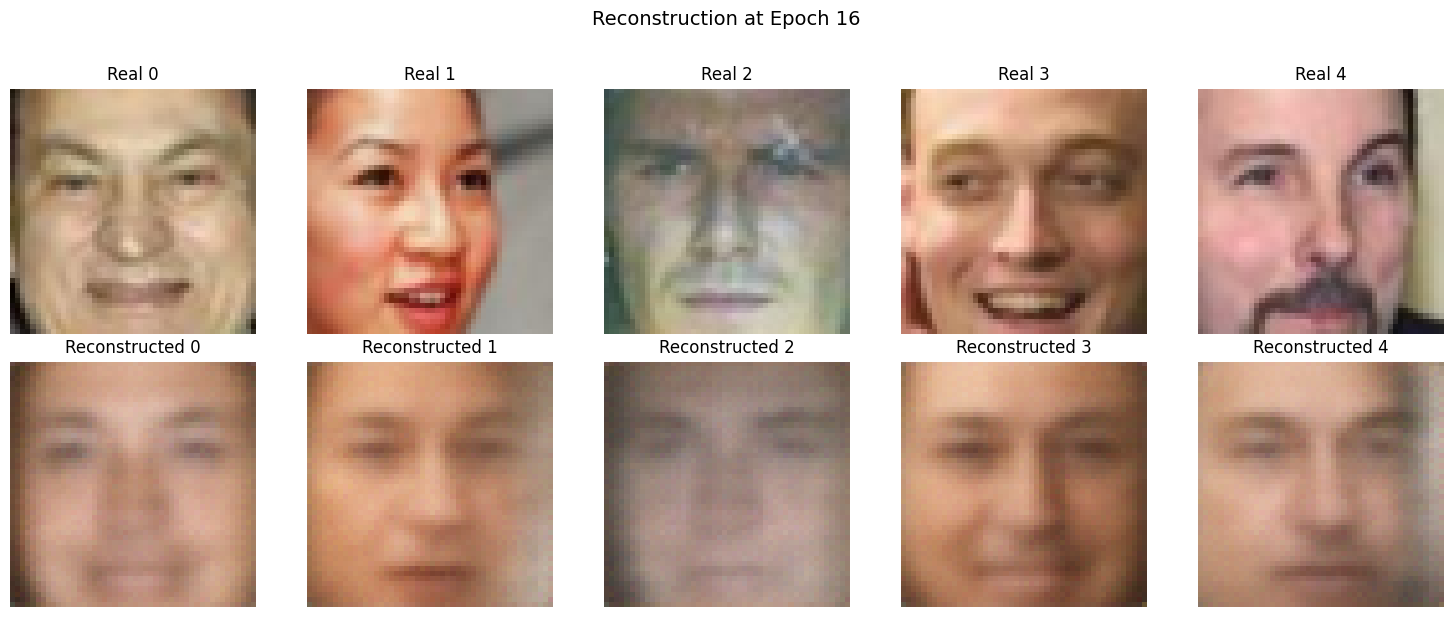

Epoch 17/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 17/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 18/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 18/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 19/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 19/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 20/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 20/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 21/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 21/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

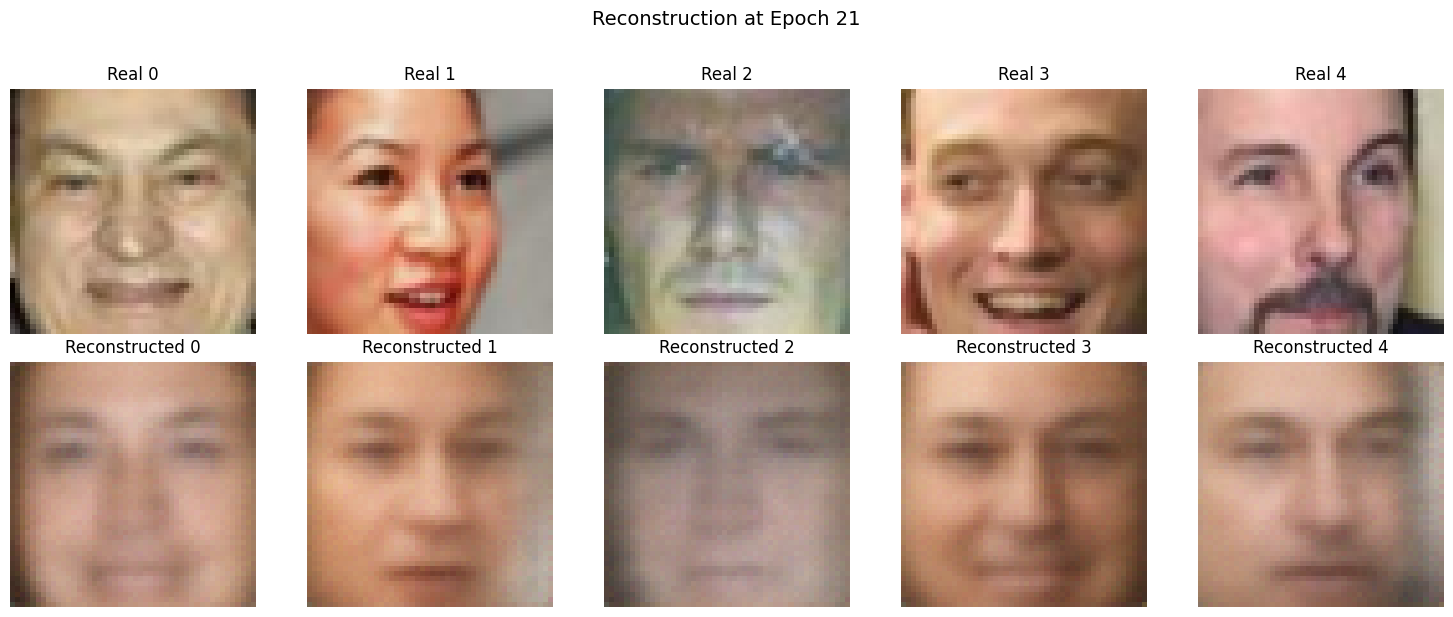

Epoch 22/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 22/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 23/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 23/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 24/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 24/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 25/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 25/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 26/26 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 26/26 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

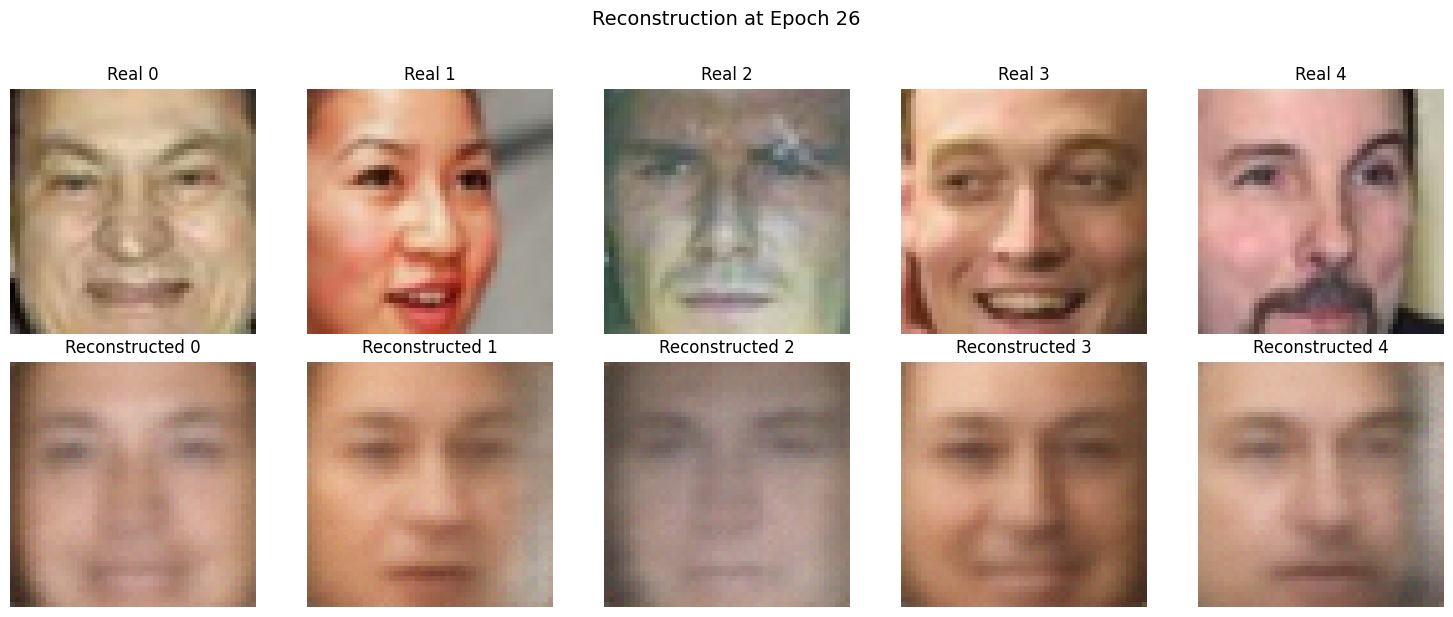

In [246]:
dim_code = 128
criterion = loss_vae
model_vae = VAE(in_channels=3, dim_code=dim_code).to(device)
optimizer = torch.optim.AdamW(model_vae.parameters(), lr=1e-3, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=26, eta_min=1e-6)

if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model_vae = nn.DataParallel(model_vae)

train_losses, val_losses = train_autoencoder(
    model=model_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=lr_scheduler,
    loss_func=criterion,
    device=device,
    epochs=26,
    visualize_every=5
)

In [324]:
model.eval()
latents, _ = model_vae.module.encode(train_images.to(device).float())
latents = latents.detach().cpu().float() / 255.

In [325]:
# LSHForest устарел и был удален из sklearn
from sklearn.neighbors import NearestNeighbors
lshf = NearestNeighbors(n_neighbors=5, metric='cosine').fit(latents)

In [326]:
def get_similar(image, n_neighbors=11):
  """Принимает одиночное изображение (тензор или numpy) и находит k ближайших

  лиц.
  """
  if image.max() > 1.0:
    image = image / 255.0

  with torch.no_grad():
    latent, _ = model_vae.module.encode(image)
    latent_np = latent.detach().cpu().numpy()

  distances, indices = lshf.kneighbors(latent_np, n_neighbors=n_neighbors)

  # Извлекаем соседей строго по найденным индексам первой строки батча:
  matched_indices = indices[0]
  neighbors = train_images[matched_indices]

  return distances[0], neighbors

In [327]:
def show_similar(image, n_neighbors=11):
  distances, neighbors = get_similar(image, n_neighbors=n_neighbors)

  def to_hwc(img):
    if isinstance(img, torch.Tensor):
      img = img.detach().cpu().numpy()
    if img.ndim == 4:
      img = img[0]
    if img.ndim == 3 and img.shape[0] in [1, 3]:
      img = np.transpose(img, (1, 2, 0))
    if img.max() > 1.0:
      img = img / 255.0
    return np.clip(img, 0.0, 1.0)

  plt.figure(figsize=(14, 8))

  # 1. Запрос
  plt.subplot(3, 4, 1)
  plt.imshow(to_hwc(image))
  plt.title("Original image", fontweight="bold", color="red")
  plt.axis("off")

  # 2. Найденные соседи
  for i in range(min(n_neighbors, 11)):
    plt.subplot(3, 4, i + 2)
    plt.imshow(to_hwc(neighbors[i]))
    plt.title(f"Dist = {distances[i]:.3f}", fontsize=10)
    plt.axis("off")

  plt.tight_layout()
  plt.show()

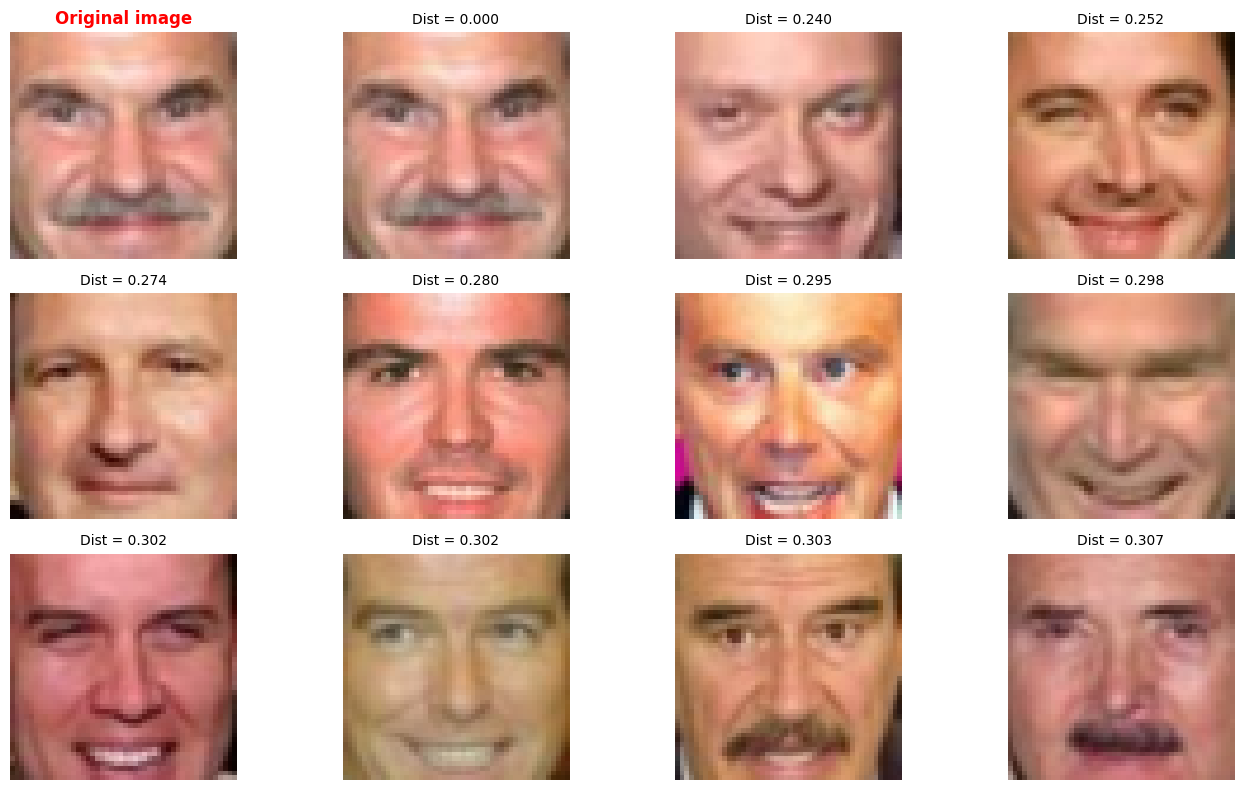

In [328]:
sample_test_img = train_images[10].unsqueeze(0).float().to(device)
show_similar(sample_test_img, n_neighbors=11)